# TB Chest X-ray Detection with MobileNetV2

## Abstract
We train a binary classifier (Tuberculosis vs Normal) on the NLM/Kaggle *TB Chest Radiography Database* using two-stage transfer learning on MobileNetV2. We then validate on two independent cohorts — the **Montgomery County** and **Shenzhen Hospital** datasets — to probe generalisation. Key findings include the in-domain vs out-of-domain AUC gap, calibration quality measured by Expected Calibration Error (ECE), and deployment size/accuracy trade-offs for an INT8 TFLite model.

**Datasets**
- *Training/test (in-domain):* `tawsifurrahman/tuberculosis-tb-chest-xray-dataset` (3 500 Normal, 700 TB)
- *External validation:* NLM Montgomery County CXR Set (80 Normal, 58 TB) + NLM Shenzhen Hospital CXR Set (326 Normal, 336 TB)

**Model:** MobileNetV2 (ImageNet) + GlobalAveragePooling + Dropout(0.2) + Dense(1)  
**Loss:** Focal loss with class-dependent α (Lin et al., 2017)  
**Evaluation:** ROC-AUC, PR-AUC, sensitivity, specificity — all with bootstrap 95% CIs

---
## 0 · Environment Setup

**Local (macOS M-series) — one-time setup:**
```bash
python3 -m venv .venv && source .venv/bin/activate
pip install tensorflow-macos tensorflow-metal \
    opencv-python-headless scipy scikit-learn \
    pillow matplotlib seaborn kaggle jupyter ipykernel
```
Then launch with `jupyter notebook analysis.ipynb` or open in VS Code.

> `tensorflow-metal` enables the Apple GPU (M-series). On Intel Mac or Linux, replace `tensorflow-macos tensorflow-metal` with plain `tensorflow`.

> This notebook is configured for **local execution** — there are no Google Colab dependencies.

In [1]:
# Uncomment and run once if any package is missing in your environment.
# See Section 0 markdown above for the recommended local install command.
# !pip install opencv-python-headless scipy scikit-learn pillow matplotlib seaborn kaggle

In [2]:
import os
import glob
import shutil
import random
import pathlib
import urllib.request
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from scipy import stats as scipy_stats

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)

/Users/alvinchow/analysis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# ── Configuration & Hyperparameters ─────────────────────────────────────────
IMG_SIZE       = 224    # MobileNetV2 native input resolution
BATCH_SIZE     = 32
RANDOM_SEED    = 42
EPOCHS_STAGE_1 = 15     # Head-only training
EPOCHS_STAGE_2 = 15     # Fine-tuning
LEARNING_RATE_1 = 1e-3
LEARNING_RATE_2 = 1e-5

# ── Data paths ───────────────────────────────────────────────────────────────
# All datasets are stored under DATA_DIR. Change this to an absolute path if you
# want datasets stored somewhere other than next to the notebook.
DATA_DIR = pathlib.Path("./data")

# Sub-paths (derived automatically — do not edit unless you moved files manually)
KAGGLE_DATA_DIR = DATA_DIR / "kaggle"
MONTGOMERY_DIR  = DATA_DIR / "montgomery"
SHENZHEN_DIR    = DATA_DIR / "shenzhen"

In [4]:
# Create the data directory if it doesn't exist yet (local — no Google Drive needed)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory : {DATA_DIR.resolve()}")
print(f"Kaggle dataset : {KAGGLE_DATA_DIR.resolve()}")
print(f"Montgomery     : {MONTGOMERY_DIR.resolve()}")
print(f"Shenzhen       : {SHENZHEN_DIR.resolve()}")

Data directory : /Users/alvinchow/analysis/data
Kaggle dataset : /Users/alvinchow/analysis/data/kaggle
Montgomery     : /Users/alvinchow/analysis/data/montgomery
Shenzhen       : /Users/alvinchow/analysis/data/shenzhen


In [5]:
# Reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {'YES' if tf.config.list_physical_devices('GPU') else 'NO — training will be slow'}")

TensorFlow: 2.16.2
GPU available: YES


---
## 1 · Data Ingestion
We download the Kaggle TB dataset using the Kaggle API. Place your `kaggle.json` token either in this folder or at `~/.kaggle/kaggle.json` before running.

In [6]:
def setup_kaggle_and_download():
    """
    Authenticate the Kaggle API and download the TB CXR dataset.

    Looks for kaggle.json in two places (in order):
      1. Current working directory  -> copies it to ~/.kaggle/
      2. ~/.kaggle/kaggle.json      -> uses it directly
    If neither exists, prints instructions and returns False.

    Re-running is safe: if the dataset directory already exists the download
    step is skipped entirely.
    """
    kaggle_dir      = pathlib.Path.home() / ".kaggle"
    kaggle_standard = kaggle_dir / "kaggle.json"
    kaggle_local    = pathlib.Path("kaggle.json")

    if kaggle_local.exists():
        kaggle_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy(kaggle_local, kaggle_standard)
        kaggle_standard.chmod(0o600)
        print(f"Copied kaggle.json -> {kaggle_standard}")
    elif kaggle_standard.exists():
        print(f"Found kaggle.json at {kaggle_standard}")
    else:
        print("ERROR: kaggle.json not found.")
        print("  Option A: place kaggle.json in the same folder as this notebook.")
        print("  Option B: place it at ~/.kaggle/kaggle.json")
        print("  Get it from: https://www.kaggle.com/settings -> API -> Create New Token")
        return False

    try:
        import kaggle
        kaggle.api.authenticate()
        print("Kaggle API authenticated.")
    except Exception as e:
        print(f"Authentication failed: {e}")
        return False

    dataset_name = "tawsifurrahman/tuberculosis-tb-chest-xray-dataset"
    expected_dir = KAGGLE_DATA_DIR / "TB_Chest_Radiography_Database"

    if expected_dir.exists():
        print(f"Dataset already present at: {expected_dir}")
        print("Skipping download.")
    else:
        print(f"Downloading {dataset_name} -> {KAGGLE_DATA_DIR} ...")
        KAGGLE_DATA_DIR.mkdir(parents=True, exist_ok=True)
        kaggle.api.dataset_download_files(
            dataset_name, path=str(KAGGLE_DATA_DIR), unzip=True
        )
        print("Download complete.")

    return True

---
## 2 · Data Splitting

> **Patient-level note:** `train_test_split` here divides on image paths. If any patient
> contributes more than one image, that patient could appear in both train and test, inflating
> the test metric. The Kaggle TB dataset does not expose patient IDs in a standardised way;
> if you have access to patient metadata, replace this with `GroupShuffleSplit` keyed on
> patient ID to enforce a proper patient-level split.

Split: **80% train / 10% validation / 10% test**, stratified by class.

In [7]:
def prepare_data_splits():
    base_dir = KAGGLE_DATA_DIR / "TB_Chest_Radiography_Database"

    normal_paths = glob.glob(str(base_dir / "Normal" / "*.*"))
    tb_paths     = glob.glob(str(base_dir / "Tuberculosis" / "*.*"))

    print(f"Normal: {len(normal_paths)}  |  TB: {len(tb_paths)}")

    all_paths  = normal_paths + tb_paths
    all_labels = [0] * len(normal_paths) + [1] * len(tb_paths)

    X_train, X_temp, y_train, y_temp = train_test_split(
        all_paths, all_labels,
        test_size=0.2, stratify=all_labels, random_state=RANDOM_SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5, stratify=y_temp, random_state=RANDOM_SEED
    )

    print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

---
## 3 · Preprocessing Pipeline

MobileNetV2 was pretrained with `mobilenet_v2.preprocess_input`, which maps pixel values
from **[0, 255] → [−1, 1]**. Using plain `/255.0` (→ [0, 1]) mismatches the pretrained
feature statistics and weakens transfer learning. All image paths — training, validation,
test, external, and the TFLite calibration generator — use the same transform.

In [8]:
def image_preprocessing(path, label):
    img = tf.io.read_file(path)
    # decode_image handles PNG, JPEG, BMP automatically
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    # MobileNetV2 contract: [0,255] -> [-1,1]
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label


def image_augmentation(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label


def build_dataset(paths, labels, train=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(image_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.map(image_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(buffer_size=1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

---
## 4 · Model Architecture

**Backbone:** MobileNetV2 (ImageNet pretrained, `include_top=False`)  
**Head:** GlobalAveragePooling2D → Dropout(0.2) → Dense(1, sigmoid)  
**Stage 1:** Backbone frozen, train head only (15 epochs)  
**Stage 2:** Unfreeze top 50 backbone layers, fine-tune with LR=1e-5 (15 epochs)

In [9]:
def build_mobilenet_model():
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs, name="TB_Detector")
    return model, backbone

In [10]:
def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal loss with class-dependent alpha (Lin et al., 2017).
    alpha applies to positives (TB); (1-alpha) applies to negatives (Normal).
    This is the correct formulation for handling the 5:1 class imbalance.
    """
    def loss(y_true, y_pred):
        y_true  = tf.cast(y_true, tf.float32)
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)   # class-dependent
        return tf.reduce_mean(alpha_t * tf.pow(1.0 - p_t, gamma) * bce)
    return loss

In [11]:
callbacks_stage1 = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

callbacks_stage2 = [
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1)
]

In [12]:
def train_model(model, backbone, train_ds, val_ds):
    """
    Two-stage transfer learning.
    Both stages use the same focal loss for a consistent loss scale.
    Gradient clipping (clipnorm=1.0) guards against the NaN divergence that can
    occur on some random initialisations (observed during cross-validation).
    """
    # Stage 1: head only
    print("\nStage 1: Training head (backbone frozen) ...")
    backbone.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_1, clipnorm=1.0),
        loss=focal_loss(alpha=0.25, gamma=2.0),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    history1 = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_STAGE_1, callbacks=callbacks_stage1)

    # Stage 2: fine-tune top 50 backbone layers
    print("\nStage 2: Fine-tuning (top 50 backbone layers) ...")
    backbone.trainable = True
    for layer in backbone.layers[:-50]:
        layer.trainable = False
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_2, clipnorm=1.0),
        loss=focal_loss(alpha=0.25, gamma=2.0),   # same loss as Stage 1
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    history2 = model.fit(train_ds, validation_data=val_ds,
                         epochs=EPOCHS_STAGE_2, callbacks=callbacks_stage2)

    return model, history1, history2

---
## 5 · Training Pipeline

Running `Restart & Run All` from here will:
1. Download the dataset via Kaggle API (skipped if already present)
2. Split into train/val/test
3. Build and train the model (two stages)
4. Evaluate on the held-out test set

In [13]:
if setup_kaggle_and_download():
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_splits()

    train_ds = build_dataset(X_train, y_train, train=True)
    val_ds   = build_dataset(X_val,   y_val,   train=False)
    test_ds  = build_dataset(X_test,  y_test,  train=False)

    SAVED_MODEL = "tb_detector.keras"
    if os.path.exists(SAVED_MODEL):
        # Crash-safe / fast path: reuse the trained model instead of retraining.
        print(f"Found {SAVED_MODEL} -> loading (skipping training).")
        model = tf.keras.models.load_model(SAVED_MODEL, compile=False)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(LEARNING_RATE_2),
            loss=focal_loss(alpha=0.25, gamma=2.0),
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
        )
        backbone = model.get_layer("mobilenetv2_1.00_224")
    else:
        model, backbone = build_mobilenet_model()
        model, h1, h2   = train_model(model, backbone, train_ds, val_ds)
        model.save(SAVED_MODEL)
        print(f"Saved trained model -> {SAVED_MODEL}")

    print("\nQuick test-set check (not the final evaluation):")
    loss, acc, auc_score = model.evaluate(test_ds)
    print(f"Loss: {loss:.4f}  |  Acc: {acc:.4f}  |  AUC: {auc_score:.4f}")
else:
    print("Workflow aborted: dataset download failed.")

Copied kaggle.json -> /Users/alvinchow/.kaggle/kaggle.json
Kaggle API authenticated.
Dataset already present at: data/kaggle/TB_Chest_Radiography_Database
Skipping download.
Normal: 3500  |  TB: 700
Train: 3360  Val: 420  Test: 420


2026-06-18 09:34:07.447547: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-18 09:34:07.447579: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-18 09:34:07.447584: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-06-18 09:34:07.447614: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-18 09:34:07.447624: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found tb_detector.keras -> loading (skipping training).

Quick test-set check (not the final evaluation):


2026-06-18 09:34:08.979515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.9970 - auc: 0.9998 - loss: 0.0027
Loss: 0.0034  |  Acc: 0.9929  |  AUC: 0.9995


In [14]:
model.summary()

Model: "TB_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,856,385 (7.08 MB)

 Non-trainable params: 402,880 (1.54 MB)

---
## 6 · Evaluation

**Protocol (leakage-safe):**
1. Select the operating threshold on the **validation set** at sensitivity ≥ 0.90 — the clinical rationale for screening is to minimise missed TB cases (false negatives).
2. Apply that threshold to the **test set** once — no re-optimisation.
3. Report **ROC-AUC**, **PR-AUC** (more informative under class imbalance), sensitivity, and specificity with **bootstrapped 95% CIs** (2 000 resamples).

Raw accuracy is not emphasised: with an 83/17 Normal/TB split a trivial classifier scores 0.83.

In [15]:
def collect_predictions(model, dataset):
    y_true, y_prob = [], []
    for x, y in dataset:
        preds = model.predict(x, verbose=0).ravel()
        y_prob.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())
    return np.array(y_true), np.array(y_prob)


def bootstrap_ci(y_true, y_prob, threshold, n_resamples=2000, confidence=0.95):
    """Percentile bootstrap CIs on AUC, sensitivity, and specificity."""
    rng = np.random.default_rng(RANDOM_SEED)
    n   = len(y_true)
    aucs, senss, specs = [], [], []

    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true[idx], y_prob[idx]
        if len(np.unique(yt)) < 2:
            continue
        aucs.append(roc_auc_score(yt, yp))
        yhat = (yp >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        senss.append(tp / (tp + fn + 1e-9))
        specs.append(tn / (tn + fp + 1e-9))

    a = (1 - confidence) / 2
    ci = lambda arr: np.percentile(arr, [a * 100, (1 - a) * 100])
    return {"auc_ci": ci(aucs), "sens_ci": ci(senss), "spec_ci": ci(specs)}


def evaluate_model_safe(model, val_ds, test_ds, target_sensitivity=0.90):
    """
    1. Select threshold on val set (sensitivity >= target_sensitivity).
    2. Evaluate on test set: ROC-AUC, PR-AUC, bootstrapped CIs.
    """
    # Validation: threshold selection
    y_val_true, y_val_prob = collect_predictions(model, val_ds)
    fpr_v, tpr_v, thr_v = roc_curve(y_val_true, y_val_prob)
    val_auc = auc(fpr_v, tpr_v)
    idx = np.argmax(tpr_v >= target_sensitivity)
    selected_threshold = float(thr_v[idx])

    print("=" * 55)
    print("VALIDATION SET")
    print(f"  ROC-AUC:   {val_auc:.4f}")
    print(f"  Threshold  (sens >= {target_sensitivity:.2f}): {selected_threshold:.4f}")
    print(f"  Sensitivity at op pt: {tpr_v[idx]:.4f}")
    print(f"  Specificity at op pt: {1 - fpr_v[idx]:.4f}")

    plt.figure(figsize=(6, 6))
    plt.plot(fpr_v, tpr_v, label=f"Val AUC = {val_auc:.3f}")
    plt.scatter(fpr_v[idx], tpr_v[idx], color="red", zorder=5, label="Operating point")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
    plt.xlabel("FPR"); plt.ylabel("TPR (Sensitivity)")
    plt.title("ROC — Validation Set")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # Test set: fixed threshold
    y_test_true, y_test_prob = collect_predictions(model, test_ds)
    fpr_t, tpr_t, _ = roc_curve(y_test_true, y_test_prob)
    test_auc = auc(fpr_t, tpr_t)
    pr_auc   = average_precision_score(y_test_true, y_test_prob)
    cis      = bootstrap_ci(y_test_true, y_test_prob, selected_threshold)

    y_test_pred = (y_test_prob >= selected_threshold).astype(int)
    cm = confusion_matrix(y_test_true, y_test_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-9)
    specificity = tn / (tn + fp + 1e-9)

    print("\nTEST SET (unseen)")
    print(f"  ROC-AUC:     {test_auc:.4f}  95% CI [{cis['auc_ci'][0]:.4f}, {cis['auc_ci'][1]:.4f}]")
    print(f"  PR-AUC:      {pr_auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}  95% CI [{cis['sens_ci'][0]:.4f}, {cis['sens_ci'][1]:.4f}]")
    print(f"  Specificity: {specificity:.4f}  95% CI [{cis['spec_ci'][0]:.4f}, {cis['spec_ci'][1]:.4f}]")
    print("=" * 55)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "TB"]).plot(cmap="Blues", ax=axes[0])
    axes[0].set_title("Confusion Matrix — Test Set")
    precision, recall, _ = precision_recall_curve(y_test_true, y_test_prob)
    axes[1].plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
    axes[1].set_xlabel("Recall (Sensitivity)"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall — Test Set")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test_true, y_test_pred, target_names=["Normal", "TB"], zero_division=0))

    return {"val_auc": val_auc, "test_auc": test_auc,
            "pr_auc": pr_auc, "threshold": selected_threshold, "cis": cis}

VALIDATION SET
  ROC-AUC:   1.0000
  Threshold  (sens >= 0.90): 0.6484
  Sensitivity at op pt: 1.0000
  Specificity at op pt: 1.0000


2026-06-18 09:34:16.462419: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


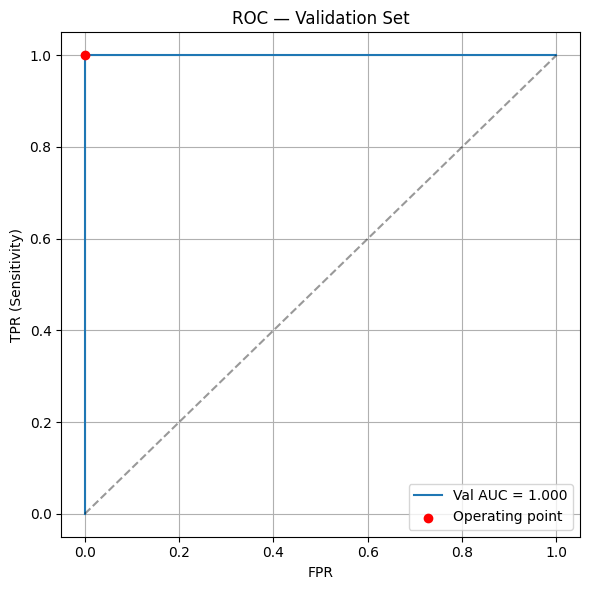

2026-06-18 09:34:18.145232: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



TEST SET (unseen)
  ROC-AUC:     0.9995  95% CI [0.9981, 1.0000]
  PR-AUC:      0.9978
  Sensitivity: 0.9286  95% CI [0.8621, 0.9848]
  Specificity: 1.0000  95% CI [1.0000, 1.0000]


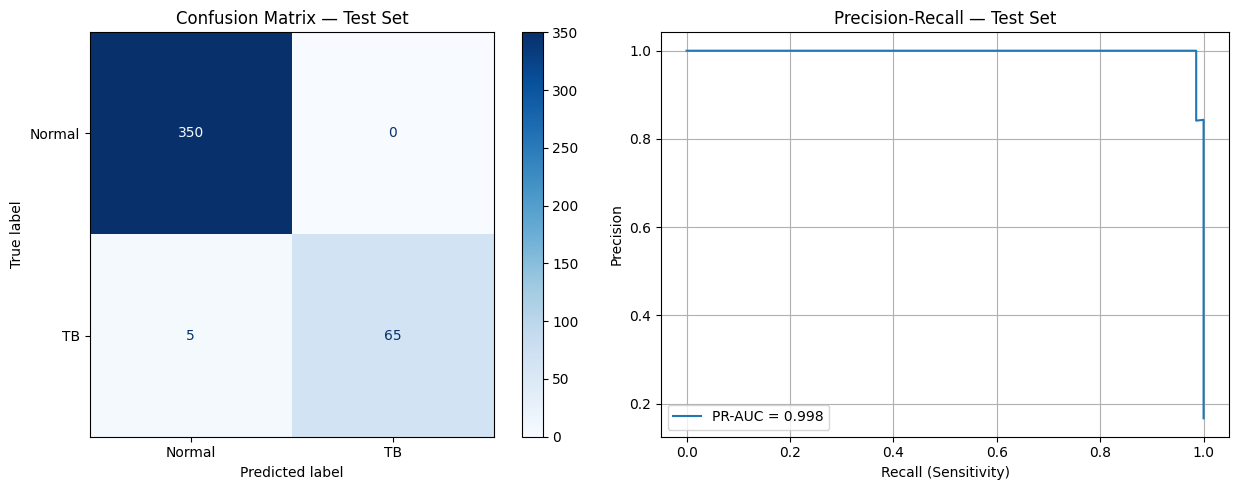


Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       350
          TB       1.00      0.93      0.96        70

    accuracy                           0.99       420
   macro avg       0.99      0.96      0.98       420
weighted avg       0.99      0.99      0.99       420



In [16]:
eval_results = evaluate_model_safe(
    model=model, val_ds=val_ds, test_ds=test_ds, target_sensitivity=0.90
)

In [17]:
# Confirm the single operating threshold derived from the validation set
threshold = eval_results["threshold"]
y_test_true, y_test_prob = collect_predictions(model, test_ds)
print(f"Operating threshold (val-set, sens >= 0.90): {threshold:.4f}")
print(f"In-domain test AUC: {roc_auc_score(y_test_true, y_test_prob):.4f}")
print()
print(classification_report(
    y_test_true, (y_test_prob >= threshold).astype(int),
    target_names=["Normal", "TB"], zero_division=0
))

Operating threshold (val-set, sens >= 0.90): 0.6484
In-domain test AUC: 0.9995

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       350
          TB       1.00      0.93      0.96        70

    accuracy                           0.99       420
   macro avg       0.99      0.96      0.98       420
weighted avg       0.99      0.99      0.99       420



2026-06-18 09:34:20.848566: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## 7 · Explainability — Grad-CAM & Integrated Gradients

We visualise *where* the model looks. For a TB detector to be clinically credible,
Grad-CAM attention should fall **inside the lung fields** — not on image borders, text
overlays, or scanner artefacts. If heat-maps land outside the lungs, that is evidence of
shortcut learning (the model is reading scanner provenance, not pathology).

Layer references use layer **names**, not positional indices, so the code survives architecture edits.

In [18]:
def get_last_conv_layer_name(model):
    backbone = model.get_layer("mobilenetv2_1.00_224")
    for layer in reversed(backbone.layers):
        if isinstance(layer, (Conv2D, DepthwiseConv2D)):
            return layer.name
    raise ValueError("No conv layer found in backbone")


def make_gradcam_heatmap(img_tensor, model):
    backbone = model.get_layer("mobilenetv2_1.00_224")

    last_conv_layer = next(
        layer for layer in reversed(backbone.layers)
        if isinstance(layer, (Conv2D, DepthwiseConv2D))
    )

    backbone_probe = tf.keras.Model(
        inputs=backbone.input,
        outputs=[last_conv_layer.output, backbone.output]
    )

    # Reference head layers by name to survive rebuilds
    gap     = model.get_layer("global_average_pooling2d")
    dropout = model.get_layer("dropout")
    dense   = model.get_layer("dense")

    with tf.GradientTape() as tape:
        conv_maps, backbone_out = backbone_probe(img_tensor, training=False)
        tape.watch(conv_maps)
        x = gap(backbone_out)
        x = dropout(x, training=False)
        preds = dense(x)
        class_score = preds[:, 0]

    grads = tape.gradient(class_score, conv_maps)
    if grads is None:
        raise RuntimeError("Gradients are None — check model structure.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_maps[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    return heatmap.numpy()


def generate_explanation(model, img_path, label_str):
    img = Image.open(img_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    img_rgb = np.array(img)

    img_tensor = tf.cast(img_rgb, tf.float32)
    img_tensor = tf.keras.applications.mobilenet_v2.preprocess_input(img_tensor)
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    pred_score = float(model.predict(img_tensor, verbose=0)[0][0])
    pred_str   = "TB" if pred_score > 0.5 else "Normal"

    heatmap = make_gradcam_heatmap(img_tensor, model)
    heatmap_res = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_col = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_rgb, 0.6, heatmap_col, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_rgb);     axes[0].set_title(f"Original (Label: {label_str})");     axes[0].axis("off")
    axes[1].imshow(heatmap, cmap="jet"); axes[1].set_title("Grad-CAM");                   axes[1].axis("off")
    axes[2].imshow(overlay);    axes[2].set_title(f"Overlay  (Pred: {pred_str} {pred_score:.2f})"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

In [19]:
# Inspect backbone layer names (useful to verify Grad-CAM layer reference)
backbone_check = model.get_layer("mobilenetv2_1.00_224")
print("Last 5 backbone layers:", [l.name for l in backbone_check.layers[-5:]])
print("Last conv layer name:", get_last_conv_layer_name(model))

Last 5 backbone layers: ['block_16_project', 'block_16_project_BN', 'Conv_1', 'Conv_1_bn', 'out_relu']
Last conv layer name: Conv_1


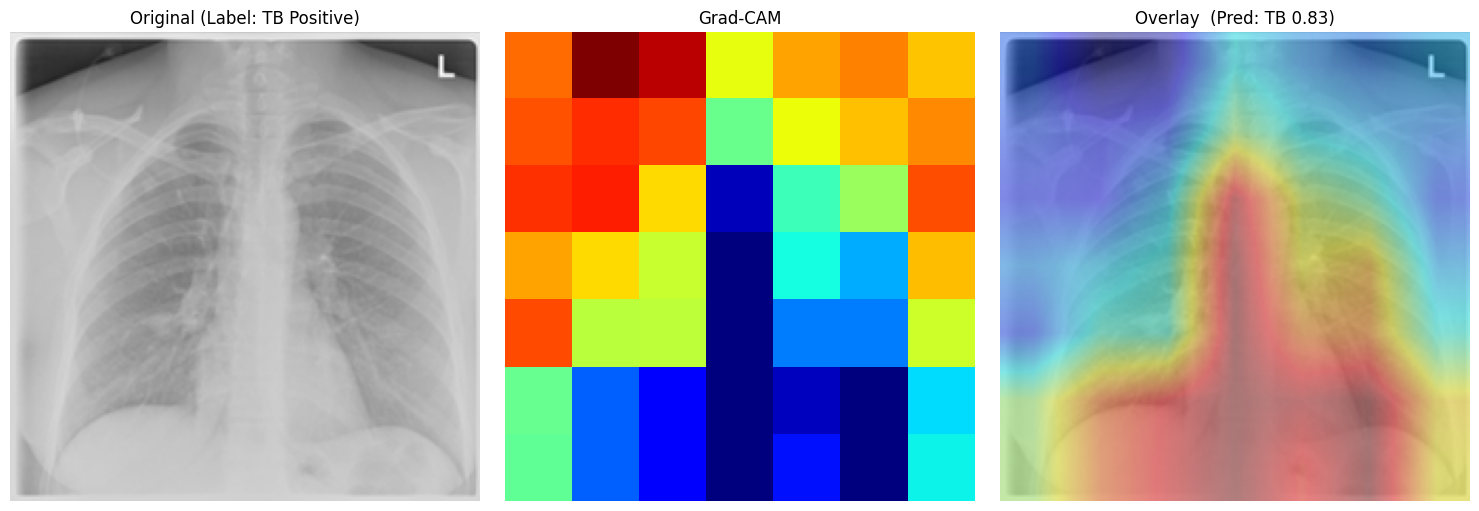

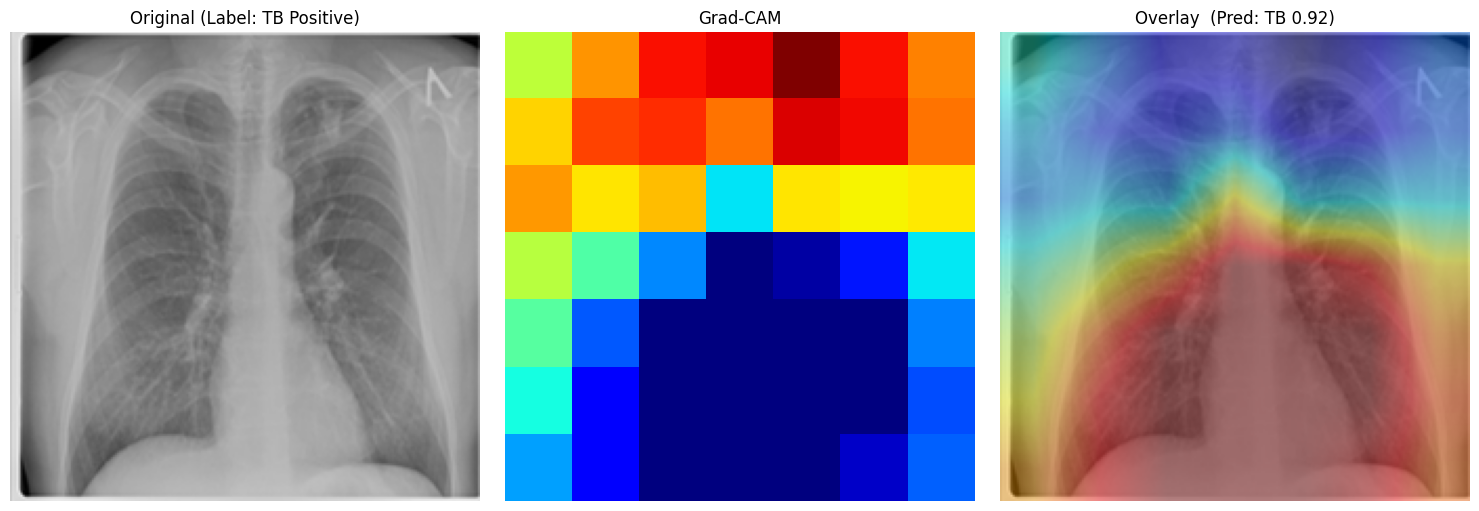

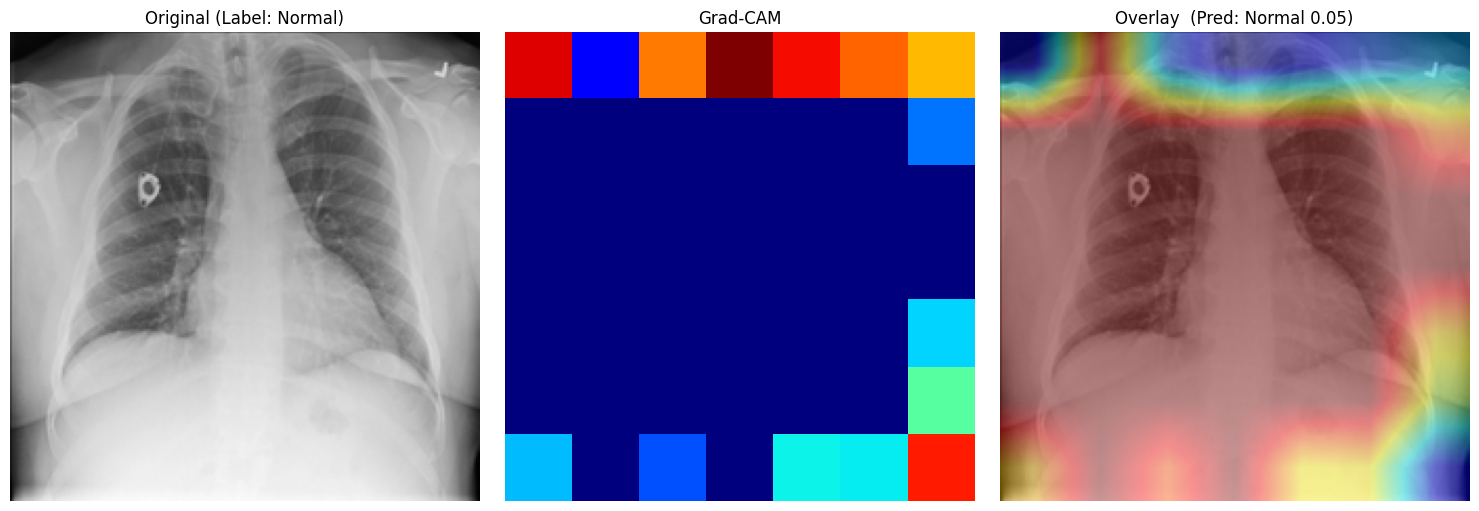

In [20]:
# Grad-CAM on one TB and one Normal from the in-domain test set
pos_idx = next(i for i, x in enumerate(y_test) if x == 1)
generate_explanation(model, X_test[pos_idx], "TB Positive")

tb_indices     = [i for i, x in enumerate(y_test) if x == 1]
normal_indices = [i for i, x in enumerate(y_test) if x == 0]
generate_explanation(model, X_test[random.choice(tb_indices)],     "TB Positive")
generate_explanation(model, X_test[random.choice(normal_indices)], "Normal")

---
## 8 · External Validation — Montgomery & Shenzhen (NLM)

The strongest test of a medical imaging model is performance on data from a **different site,
scanner, and patient population**. We use two independent TB CXR sets published by the U.S.
National Library of Medicine (Jaeger et al., 2014):

| Dataset | Images | TB | Normal |
|---|---|---|---|
| Montgomery County (MC) | 138 | 58 | 80 |
| Shenzhen Hospital (SH) | 662 | 336 | 326 |

**Label convention:** encoded in filename — `*_0.png` = Normal, `*_1.png` = TB.

> **Interpreting the gap:** A large drop in AUC from in-domain to external data is a red flag
> for *source-shortcut learning* — the model is exploiting scanner-specific artefacts rather
> than true TB pathology. The Grad-CAM sanity check (Section 7) helps diagnose this.

In [21]:
def download_and_extract(url, dest_zip, dest_dir):
    """Download a zip from url and extract it. Skips both steps if dest_dir exists."""
    dest_dir = pathlib.Path(dest_dir)
    if dest_dir.exists():
        print(f"Already downloaded: {dest_dir}")
        return
    dest_zip = pathlib.Path(dest_zip)
    if not dest_zip.exists():
        print(f"Downloading {dest_zip.name} ...")
        urllib.request.urlretrieve(url, dest_zip)
    else:
        print(f"Zip already present: {dest_zip} — skipping download.")
    print(f"Extracting -> {dest_dir} ...")
    dest_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(dest_zip, "r") as z:
        z.extractall(dest_dir)
    print("Done.")


MONTGOMERY_URL = "https://openi.nlm.nih.gov/imgs/collections/NLM-MontgomeryCXRSet.zip"
SHENZHEN_URL   = "https://openi.nlm.nih.gov/imgs/collections/ChinaSet_AllFiles.zip"

download_and_extract(MONTGOMERY_URL, DATA_DIR / "montgomery.zip", MONTGOMERY_DIR)
download_and_extract(SHENZHEN_URL,   DATA_DIR / "shenzhen.zip",   SHENZHEN_DIR)

Already downloaded: data/montgomery
Already downloaded: data/shenzhen


In [22]:
def load_nlm_dataset(image_dir, prefix):
    """
    Load NLM TB dataset. Labels are encoded in the filename:
      MCUCXR_XXXX_0.png -> Normal  |  MCUCXR_XXXX_1.png -> TB   (Montgomery)
      CHNCXR_XXXX_0.png -> Normal  |  CHNCXR_XXXX_1.png -> TB   (Shenzhen)
    """
    image_dir = pathlib.Path(image_dir)
    paths, labels = [], []

    for img_file in sorted(image_dir.glob("*.png")):
        # Skip macOS AppleDouble sidecar files (._MCUCXR_0001_0.png) from zip extraction
        if img_file.name.startswith("._"):
            continue
        parts = img_file.stem.rsplit("_", 1)
        if len(parts) != 2 or parts[1] not in ("0", "1"):
            continue
        paths.append(str(img_file))
        labels.append(int(parts[1]))

    if not paths:
        raise FileNotFoundError(
            f"[{prefix}] No labelled PNGs found in: {image_dir}\n"
            "The dataset may have extracted to a different folder. "
            "Check that the path points at the real CXR_png directory."
        )

    print(f"[{prefix}] {len(paths)} images \u2014 TB: {sum(labels)}  Normal: {len(labels)-sum(labels)}")
    return paths, labels


def find_image_dir(base, pattern="CXR_png"):
    """
    Locate the image directory, robust to:
      - __MACOSX junk folders created when a zip is made on macOS
      - the target sitting one or more levels deep
    Prefers a matching directory that actually contains real PNG images.
    """
    base = pathlib.Path(base)
    candidates = [
        p for p in base.rglob(pattern)
        if p.is_dir() and "__MACOSX" not in p.parts
    ]
    # Prefer a candidate that actually holds real (non-AppleDouble) PNGs
    for p in candidates:
        if any(f for f in p.glob("*.png") if not f.name.startswith("._")):
            return p
    if candidates:
        return candidates[0]
    return base

In [23]:
montgomery_img_dir = find_image_dir(MONTGOMERY_DIR)
shenzhen_img_dir   = find_image_dir(SHENZHEN_DIR)

X_mont,  y_mont  = load_nlm_dataset(montgomery_img_dir, "MCUCXR")
X_shenz, y_shenz = load_nlm_dataset(shenzhen_img_dir,   "CHNCXR")

X_test_ext = X_mont + X_shenz
y_test_ext = y_mont + y_shenz
print(f"Combined: {len(X_test_ext)} images — TB: {sum(y_test_ext)}  Normal: {len(y_test_ext)-sum(y_test_ext)}")

[MCUCXR] 138 images — TB: 58  Normal: 80
[CHNCXR] 662 images — TB: 336  Normal: 326
Combined: 800 images — TB: 394  Normal: 406


In [24]:
test_ds_montgomery = build_dataset(X_mont,     y_mont,     train=False)
test_ds_shenzhen   = build_dataset(X_shenz,    y_shenz,    train=False)
test_ds_external   = build_dataset(X_test_ext, y_test_ext, train=False)

EXTERNAL — Montgomery County (NLM)
VALIDATION SET
  ROC-AUC:   1.0000
  Threshold  (sens >= 0.90): 0.6484
  Sensitivity at op pt: 1.0000
  Specificity at op pt: 1.0000


2026-06-18 09:34:23.957821: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


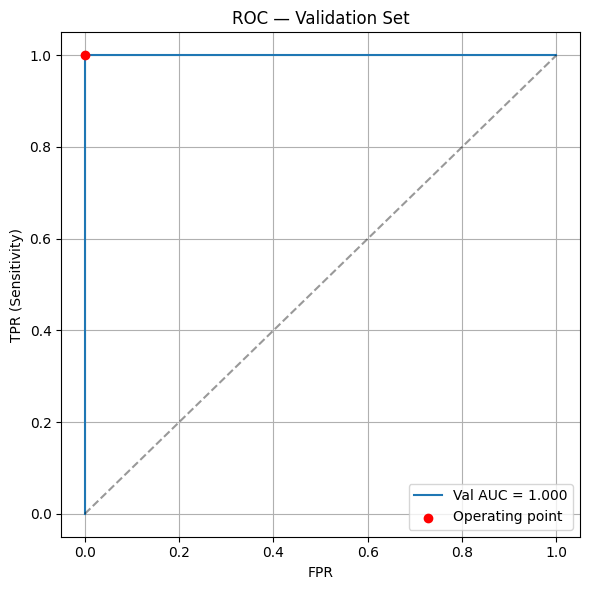

2026-06-18 09:34:26.674361: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



TEST SET (unseen)
  ROC-AUC:     0.6978  95% CI [0.6072, 0.7842]
  PR-AUC:      0.5608
  Sensitivity: 0.0000  95% CI [0.0000, 0.0000]
  Specificity: 1.0000  95% CI [1.0000, 1.0000]


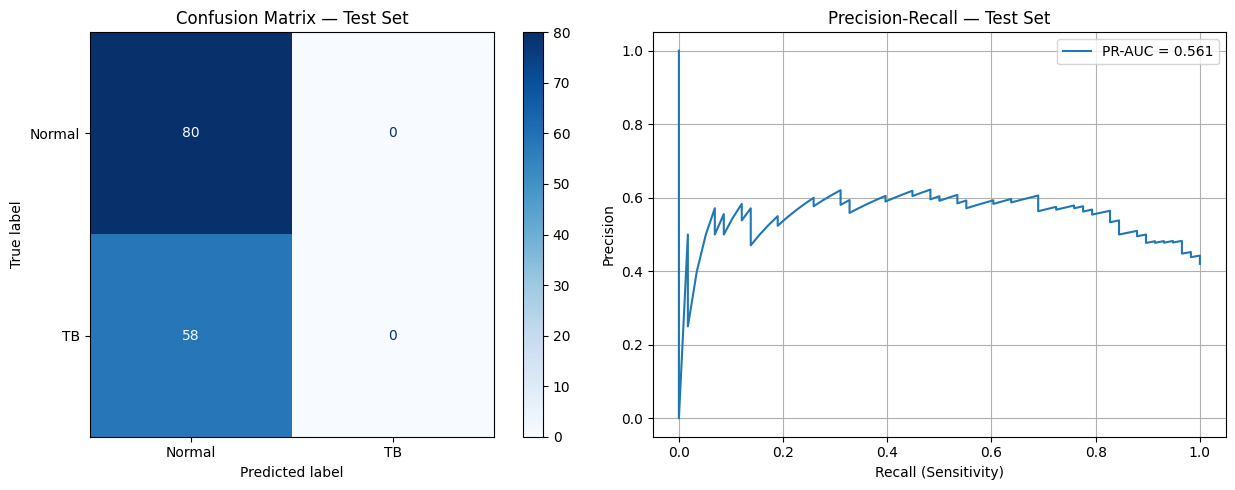


Classification Report:
              precision    recall  f1-score   support

      Normal       0.58      1.00      0.73        80
          TB       0.00      0.00      0.00        58

    accuracy                           0.58       138
   macro avg       0.29      0.50      0.37       138
weighted avg       0.34      0.58      0.43       138


EXTERNAL — Shenzhen Hospital (NLM)
VALIDATION SET
  ROC-AUC:   1.0000
  Threshold  (sens >= 0.90): 0.6484
  Sensitivity at op pt: 1.0000
  Specificity at op pt: 1.0000


2026-06-18 09:34:29.638790: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


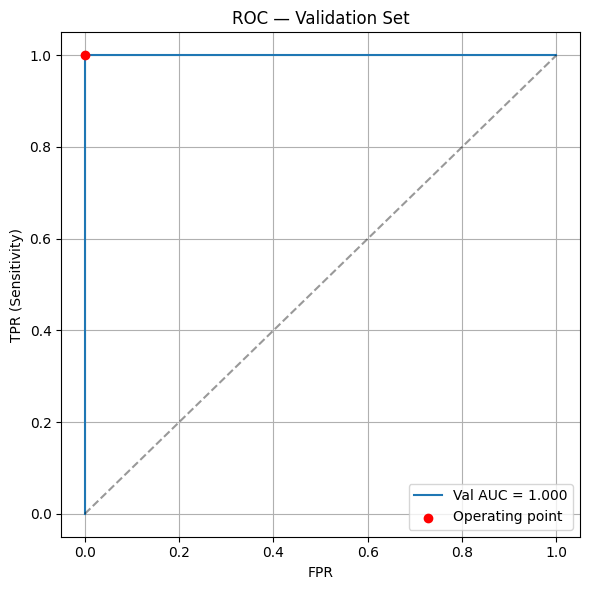

2026-06-18 09:34:35.964206: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



TEST SET (unseen)
  ROC-AUC:     0.7758  95% CI [0.7401, 0.8108]
  PR-AUC:      0.7756
  Sensitivity: 0.0238  95% CI [0.0088, 0.0411]
  Specificity: 0.9969  95% CI [0.9903, 1.0000]


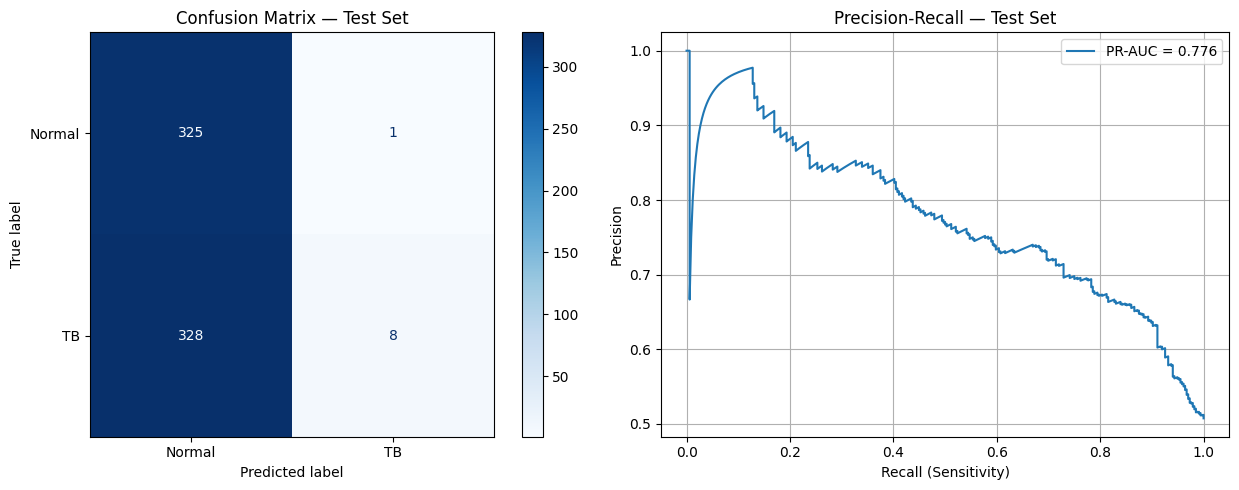


Classification Report:
              precision    recall  f1-score   support

      Normal       0.50      1.00      0.66       326
          TB       0.89      0.02      0.05       336

    accuracy                           0.50       662
   macro avg       0.69      0.51      0.36       662
weighted avg       0.70      0.50      0.35       662


EXTERNAL — Combined
VALIDATION SET
  ROC-AUC:   1.0000
  Threshold  (sens >= 0.90): 0.6484
  Sensitivity at op pt: 1.0000
  Specificity at op pt: 1.0000


2026-06-18 09:34:39.026148: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


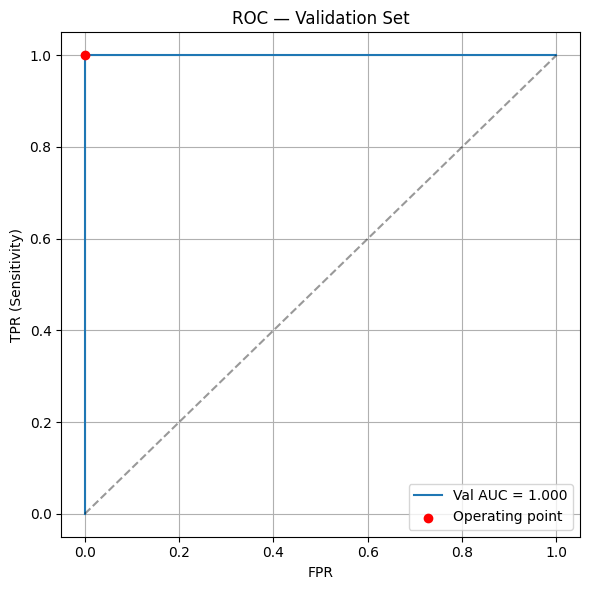

2026-06-18 09:34:46.450392: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



TEST SET (unseen)
  ROC-AUC:     0.7525  95% CI [0.7185, 0.7864]
  PR-AUC:      0.7457
  Sensitivity: 0.0203  95% CI [0.0076, 0.0354]
  Specificity: 0.9975  95% CI [0.9923, 1.0000]


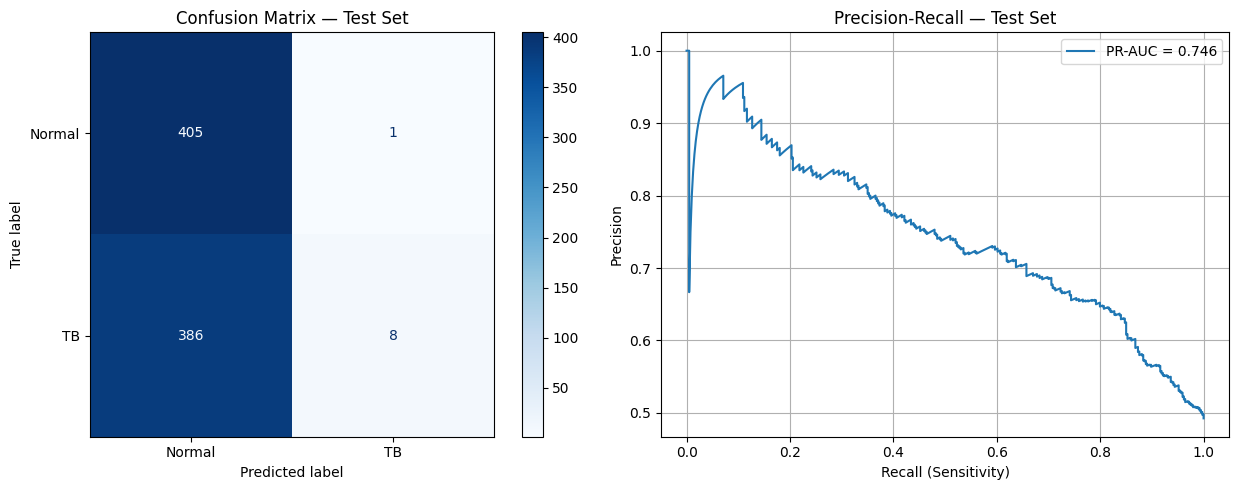


Classification Report:
              precision    recall  f1-score   support

      Normal       0.51      1.00      0.68       406
          TB       0.89      0.02      0.04       394

    accuracy                           0.52       800
   macro avg       0.70      0.51      0.36       800
weighted avg       0.70      0.52      0.36       800


Generalisation Gap Summary
--------------------------------------------
  In-domain test AUC    : 0.9995
  External — Montgomery : 0.6978
  External — Shenzhen   : 0.7758
  External — Combined   : 0.7525
--------------------------------------------
A large gap indicates source-shortcut learning.



In [25]:
print("=" * 60)
print("EXTERNAL — Montgomery County (NLM)")
print("=" * 60)
ext_mont  = evaluate_model_safe(model, val_ds, test_ds_montgomery)

print("\n" + "=" * 60)
print("EXTERNAL — Shenzhen Hospital (NLM)")
print("=" * 60)
ext_shenz = evaluate_model_safe(model, val_ds, test_ds_shenzhen)

print("\n" + "=" * 60)
print("EXTERNAL — Combined")
print("=" * 60)
ext_comb  = evaluate_model_safe(model, val_ds, test_ds_external)

print(f"""
Generalisation Gap Summary
--------------------------------------------
  In-domain test AUC    : {eval_results['test_auc']:.4f}
  External — Montgomery : {ext_mont['test_auc']:.4f}
  External — Shenzhen   : {ext_shenz['test_auc']:.4f}
  External — Combined   : {ext_comb['test_auc']:.4f}
--------------------------------------------
A large gap indicates source-shortcut learning.
""")

---
## 8b · Re-thresholding Analysis (diagnostic, no retraining)

The external sensitivity looked catastrophic (~0–2%), but external **AUC is ~0.75** — those
two facts only reconcile once we separate them:

- **AUC** measures *discrimination* — can the model rank TB above Normal at all?
- **Sensitivity/specificity** depend on the **threshold**, which we picked on the Kaggle
  validation set (0.6484). On external data the score distribution shifts downward, so almost
  nothing crosses that threshold → everything is called "Normal".

Below we re-pick the operating point **directly on each external set** to see what the model's
discrimination actually allows.

> ⚠️ **This is an optimistic "oracle" threshold** (tuned on the same data we score), shown only
> to separate threshold effects from discrimination effects. It is **not** leakage-safe or
> deployable — a real deployment threshold must be tuned on a held-out calibration split from the
> target hospital.

In [26]:
# Re-thresholding analysis: threshold effect vs discrimination effect (NO retraining)
def threshold_analysis(name, ds, in_domain_thr):
    y_true, y_prob = collect_predictions(model, ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    def metrics_at(t):
        yhat = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()
        return tp/(tp+fn+1e-9), tn/(tn+fp+1e-9)   # sensitivity, specificity

    s_id, sp_id = metrics_at(in_domain_thr)
    idx90 = np.argmax(tpr >= 0.90); t90 = thr[idx90]
    s90, sp90 = metrics_at(t90)
    jt = thr[np.argmax(tpr - fpr)]                 # Youden's J optimal point
    sj, spj = metrics_at(jt)

    print(f"\n=== {name}   (AUC = {auc_val:.3f}) ===")
    print(f"  in-domain thr {in_domain_thr:0.3f}      -> sens {s_id:0.2f} | spec {sp_id:0.2f}")
    print(f"  re-tuned  thr {t90:0.3f} (sens>=0.90) -> sens {s90:0.2f} | spec {sp90:0.2f}")
    print(f"  Youden    thr {jt:0.3f}            -> sens {sj:0.2f} | spec {spj:0.2f}")
    return auc_val

print("Same model, same predictions — only the decision threshold changes.")
thr_id = eval_results["threshold"]
for nm, ds in [("Montgomery", test_ds_montgomery),
               ("Shenzhen",   test_ds_shenzhen),
               ("Combined",    test_ds_external)]:
    threshold_analysis(nm, ds, thr_id)

print("""
Reading this:
  * 'in-domain thr' = what the notebook reported (sens ~0): the threshold is mis-set
    for external data, NOT pure discrimination failure.
  * 're-tuned thr'  = if we DEMAND 90% sensitivity, this is the specificity the model
    can actually deliver on external data. Low specificity here = the AUC ceiling
    (~0.75) is the real limit, which only retraining (segmentation / multi-source /
    harmonisation) can lift.
""")

Same model, same predictions — only the decision threshold changes.


2026-06-18 09:34:50.285577: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== Montgomery   (AUC = 0.698) ===
  in-domain thr 0.648      -> sens 0.00 | spec 1.00
  re-tuned  thr 0.050 (sens>=0.90) -> sens 0.91 | spec 0.29
  Youden    thr 0.081            -> sens 0.83 | spec 0.54


2026-06-18 09:34:55.665643: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



=== Shenzhen   (AUC = 0.776) ===
  in-domain thr 0.648      -> sens 0.02 | spec 1.00
  re-tuned  thr 0.148 (sens>=0.90) -> sens 0.90 | spec 0.47
  Youden    thr 0.233            -> sens 0.68 | spec 0.75

=== Combined   (AUC = 0.752) ===
  in-domain thr 0.648      -> sens 0.02 | spec 1.00
  re-tuned  thr 0.105 (sens>=0.90) -> sens 0.91 | spec 0.33
  Youden    thr 0.195            -> sens 0.71 | spec 0.69

Reading this:
  * 'in-domain thr' = what the notebook reported (sens ~0): the threshold is mis-set
    for external data, NOT pure discrimination failure.
  * 're-tuned thr'  = if we DEMAND 90% sensitivity, this is the specificity the model
    can actually deliver on external data. Low specificity here = the AUC ceiling
    (~0.75) is the real limit, which only retraining (segmentation / multi-source /
    harmonisation) can lift.



2026-06-18 09:35:04.119758: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


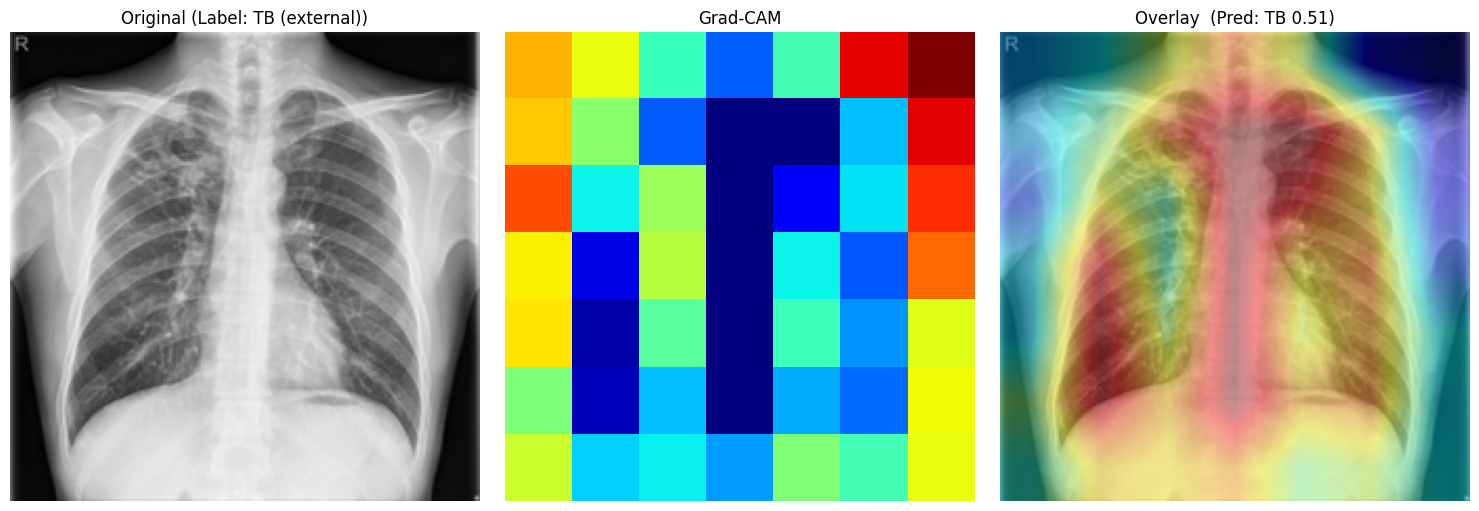

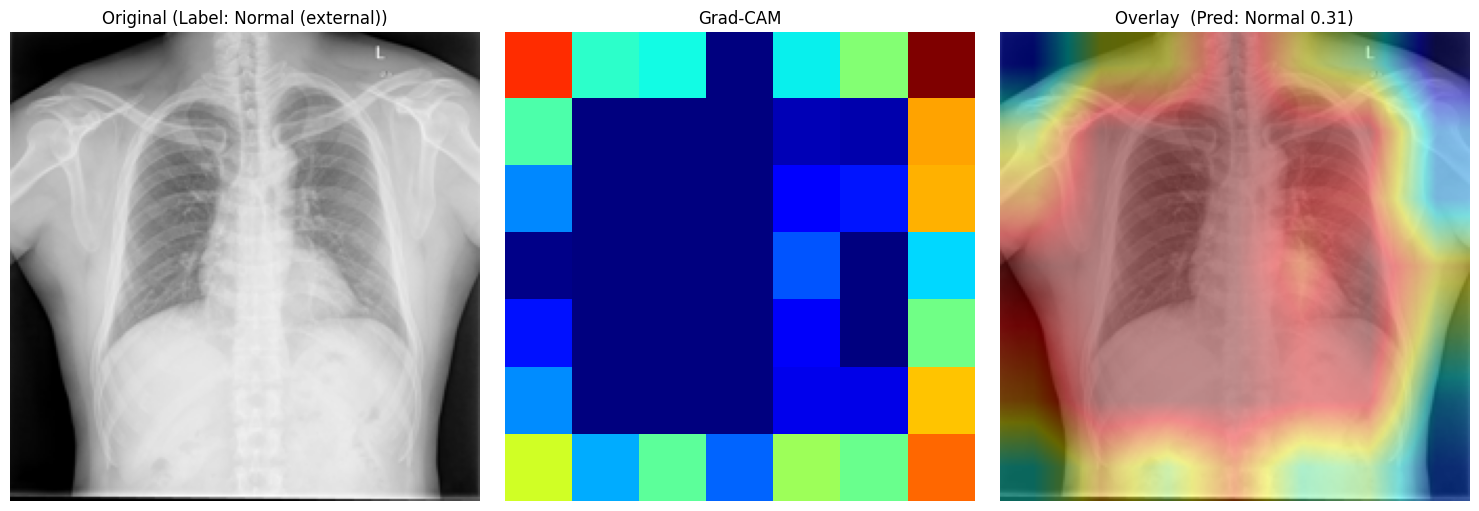

In [27]:
# Grad-CAM on external samples — check whether attention falls inside lungs
tb_ext_indices     = [i for i, x in enumerate(y_test_ext) if x == 1]
normal_ext_indices = [i for i, x in enumerate(y_test_ext) if x == 0]

generate_explanation(model, X_test_ext[random.choice(tb_ext_indices)],     "TB (external)")
generate_explanation(model, X_test_ext[random.choice(normal_ext_indices)], "Normal (external)")

---
## 9 · Calibration — Temperature Scaling

A well-calibrated model produces probabilities that match empirical frequencies:
images assigned 80% TB probability should actually have TB ~80% of the time.
We measure this with **Expected Calibration Error (ECE)** and a reliability diagram.

**Method:**
- Extract **pre-sigmoid logits** directly from the final Dense layer (avoids the numerical
  instability of inverting saturated probabilities with `log(p/(1-p))`).
- Fit a single temperature parameter `T` on the **validation set** by minimising
  binary cross-entropy on `sigmoid(logits / T)`.
- Report ECE **before and after** scaling on the held-out **test set**.

2026-06-18 09:35:08.921719: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:10.527024: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


ECE before temperature scaling: 0.7697
Optimal temperature:            0.1159
ECE after  temperature scaling: 0.8328
Improvement:                    -0.0631


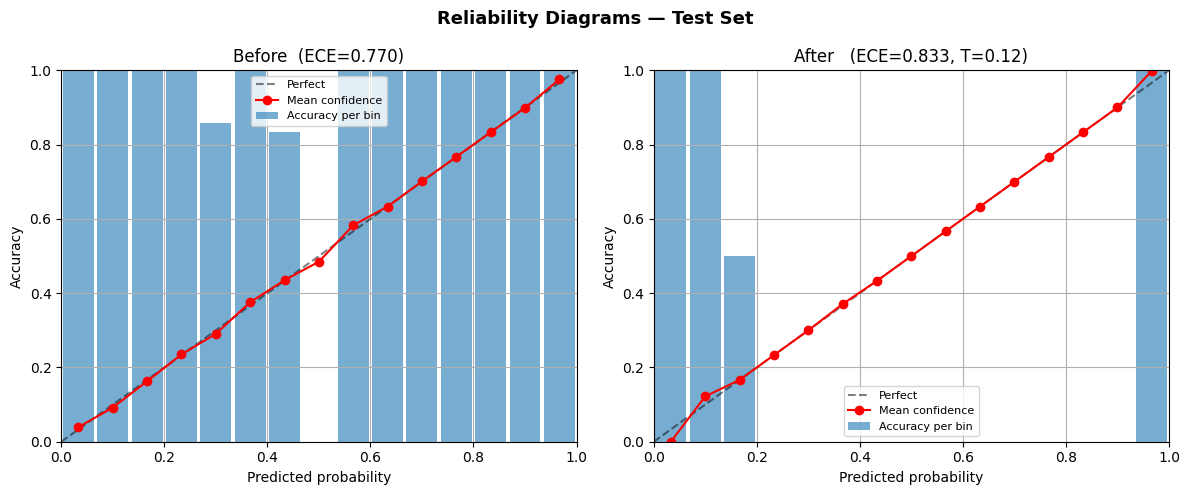

In [28]:
def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins    = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if mask.any():
            acc  = np.mean((y_prob[mask] >= 0.5) == y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += np.abs(acc - conf) * mask.mean()
    return ece


def plot_reliability(y_true, y_prob, title, n_bins=15, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    accs, confs = [], []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        accs.append(np.mean((y_prob[mask] >= 0.5) == y_true[mask]) if mask.any() else 0)
        confs.append(np.mean(y_prob[mask]) if mask.any() else centers[i])
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
    ax.bar(centers, accs, width=0.06, alpha=0.6, label="Accuracy per bin")
    ax.plot(centers, confs, "o-", color="red", label="Mean confidence")
    ax.set(xlim=(0,1), ylim=(0,1), xlabel="Predicted probability", ylabel="Accuracy", title=title)
    ax.legend(fontsize=8); ax.grid(True)


# Extract pre-sigmoid logits WITHOUT mutating `model`.
# Approach: a feature extractor (everything up to the layer before the final
# Dense), then apply the Dense weights manually with NO activation. This avoids
#   (a) mutating the shared Dense layer's activation (which corrupts `model`), and
#   (b) clone_model, which fails on a model compiled with a custom focal loss.
feature_model = tf.keras.Model(model.input, model.layers[-2].output)
_dense_W, _dense_b = model.layers[-1].get_weights()

def collect_logits(feature_model, dataset):
    y_true_all, logits_all = [], []
    for x, y in dataset:
        feats  = feature_model(x, training=False).numpy()   # (B, 1280)
        logits = (feats @ _dense_W + _dense_b).ravel()      # pre-sigmoid
        logits_all.extend(logits.tolist())
        y_true_all.extend(y.numpy().tolist())
    return np.array(y_true_all), np.array(logits_all)

y_val_true_cal,  y_val_logits  = collect_logits(feature_model, val_ds)
y_test_true_cal, y_test_logits = collect_logits(feature_model, test_ds)

y_test_probs_before = tf.sigmoid(y_test_logits).numpy()
ece_before = expected_calibration_error(y_test_true_cal, y_test_probs_before)
print(f"ECE before temperature scaling: {ece_before:.4f}")


def fit_temperature(logits, labels, epochs=300, lr=0.05):
    """
    Temperature scaling (Guo et al., 2017).
    Optimises a single scalar T by minimising BCE on sigmoid(logits / T).

    Implementation notes:
      - Uses a plain tf.Variable (not a tf.keras.Model subclass): in Keras 3,
        raw tf.Variables attached to a Model are NOT tracked in
        trainable_variables, which silently breaks gradient updates.
      - Parameterises log(T) so T stays strictly positive without a constraint.
      - Uses sigmoid_cross_entropy_with_logits for numerical stability
        (no manual sigmoid before the loss).
    """
    logits_t = tf.constant(logits, dtype=tf.float32)
    labels_t = tf.cast(labels, tf.float32)
    log_T    = tf.Variable(0.0, dtype=tf.float32)   # T = exp(log_T) = 1.0 initially
    opt      = tf.keras.optimizers.Adam(lr)

    for _ in range(epochs):
        with tf.GradientTape() as tape:
            scaled = logits_t / tf.exp(log_T)
            loss = tf.reduce_mean(
                tf.nn.sigmoid_cross_entropy_with_logits(labels=labels_t, logits=scaled)
            )
        grads = tape.gradient(loss, [log_T])
        opt.apply_gradients(zip(grads, [log_T]))

    return float(tf.exp(log_T).numpy())


# Fit on VALIDATION logits, evaluate on TEST
temperature = fit_temperature(y_val_logits, y_val_true_cal)
print(f"Optimal temperature:            {temperature:.4f}")

y_test_probs_after = tf.sigmoid(y_test_logits / temperature).numpy()
ece_after = expected_calibration_error(y_test_true_cal, y_test_probs_after)
print(f"ECE after  temperature scaling: {ece_after:.4f}")
print(f"Improvement:                    {ece_before - ece_after:+.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_reliability(y_test_true_cal, y_test_probs_before, f"Before  (ECE={ece_before:.3f})", ax=ax1)
plot_reliability(y_test_true_cal, y_test_probs_after,  f"After   (ECE={ece_after:.3f}, T={temperature:.2f})", ax=ax2)
plt.suptitle("Reliability Diagrams — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

---
## 10 · Integrated Gradients

Integrated Gradients (Sundararajan et al., 2017) provides a theoretically grounded attribution
method that satisfies sensitivity and implementation invariance — properties Grad-CAM does not
guarantee. Use both methods together for a fuller picture of model attention.

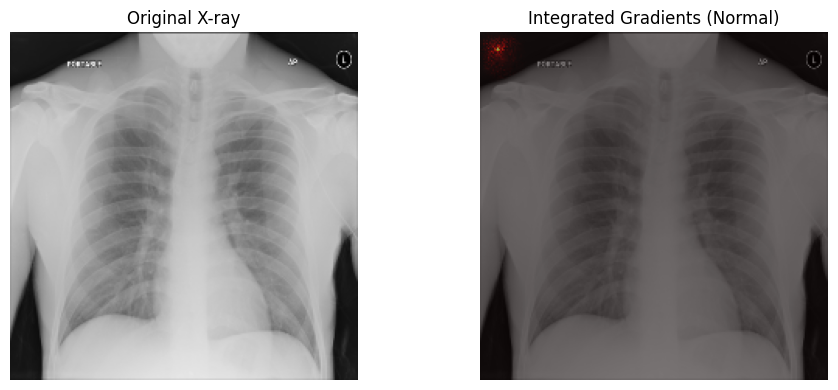

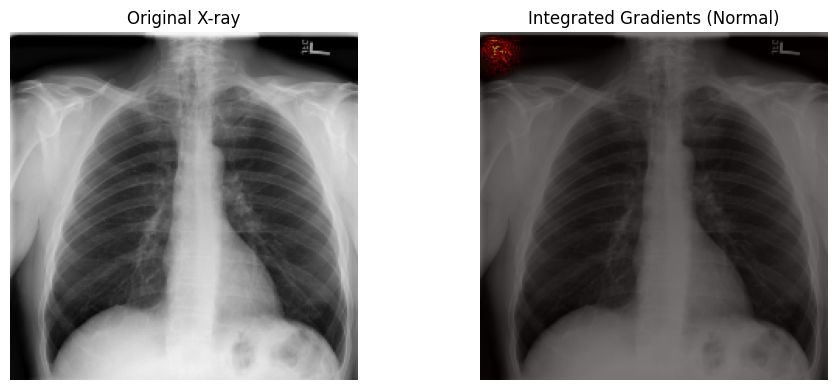

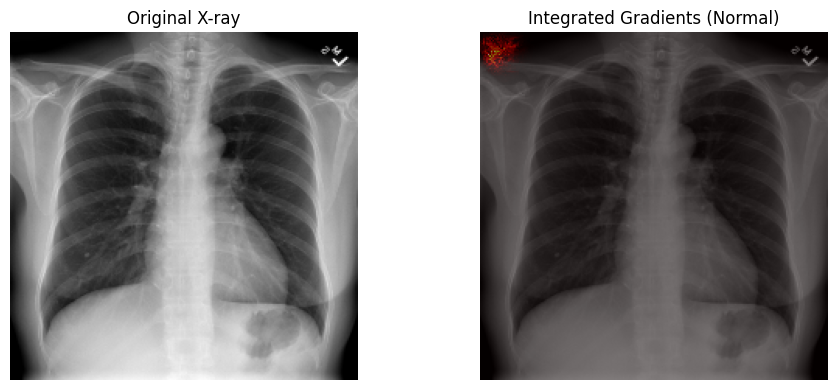

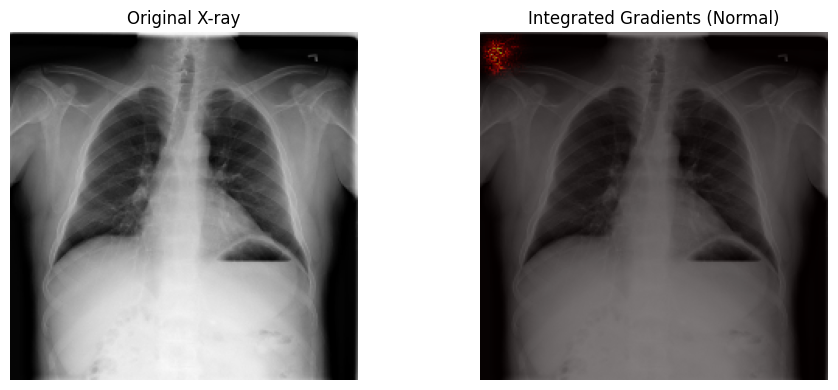

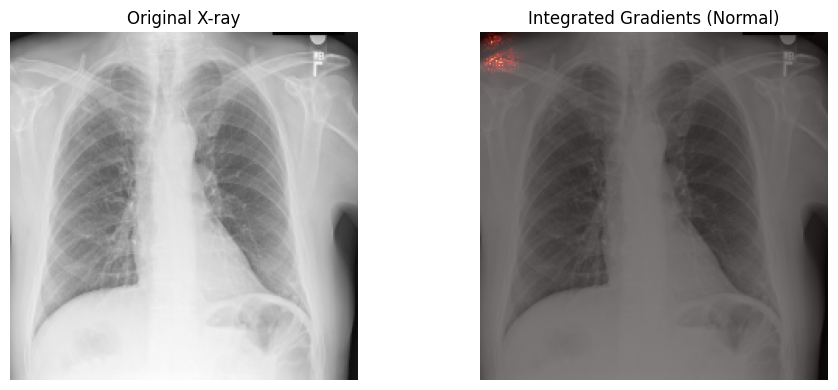

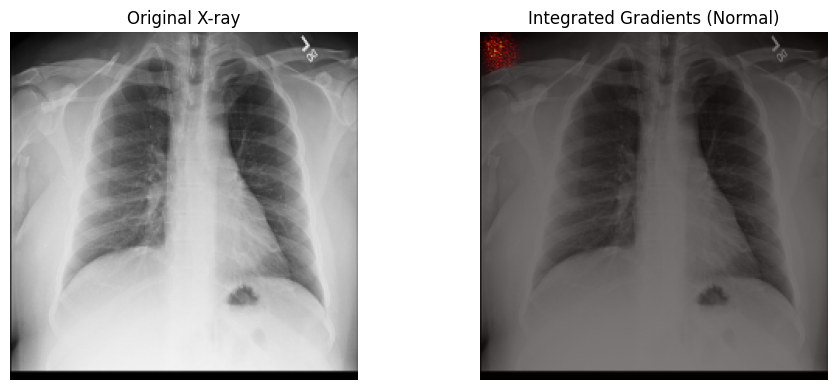

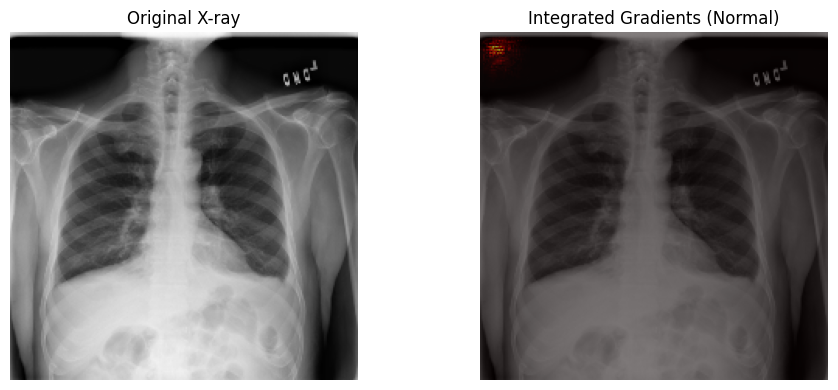

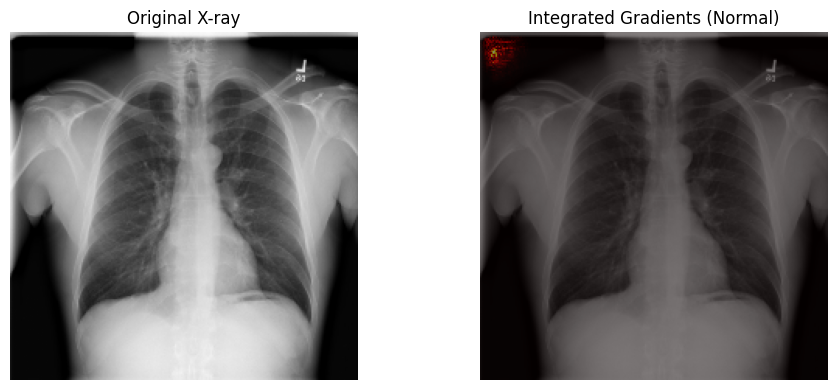

In [29]:
def integrated_gradients(model, img_tensor, baseline=None, steps=50):
    if baseline is None:
        baseline = tf.zeros_like(img_tensor)
    img_tensor = tf.cast(img_tensor, tf.float32)
    alphas = tf.reshape(tf.linspace(0.0, 1.0, steps), (-1, 1, 1, 1))
    interpolated = baseline + alphas * (img_tensor - baseline)
    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        outputs = model(interpolated)[:, 0]
    grads  = tape.gradient(outputs, interpolated)
    avg_g  = tf.reduce_mean(grads, axis=0)
    ig     = tf.reduce_sum(tf.abs((img_tensor - baseline) * avg_g), axis=-1)
    ig    /= tf.reduce_max(ig) + 1e-8
    return ig[0].numpy()


def plot_ig(img, ig_map, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img);         axes[0].set_title("Original X-ray"); axes[0].axis("off")
    axes[1].imshow(img)
    axes[1].imshow(ig_map, cmap="hot", alpha=0.5)
    axes[1].set_title(f"Integrated Gradients {title}"); axes[1].axis("off")
    plt.tight_layout(); plt.show()


for x_batch, y_batch in test_ds.take(1):
    # Show one TB and one Normal
    for i in range(min(len(x_batch), 8)):
        label = int(y_batch[i].numpy())
        img   = x_batch[i:i+1]
        ig    = integrated_gradients(model, img)
        # Convert from [-1,1] back to [0,1] for display
        img_display = (x_batch[i].numpy() + 1) / 2
        plot_ig(img_display, ig, title=f"({'TB' if label else 'Normal'})")
    break

---
## 11 · Deployment — INT8 TFLite Quantization

We convert the trained model to 8-bit integer TFLite for mobile/edge deployment.
**We then evaluate the INT8 model on the full test set** to report:
- AUC delta (float vs INT8)
- Sensitivity/specificity delta
- Inference latency per image

Without this step, "we deployed an 8-bit model" is not a result — it is an
unvalidated claim.

In [30]:
import subprocess, sys

def convert_to_tflite_isolated(keras_path="tb_detector.keras",
                               out_path="tb_detector_dynamic.tflite"):
    """
    Convert the saved Keras model to a dynamic-range INT8 TFLite file in a
    SEPARATE PROCESS.

    Why a subprocess: the tensorflow-macos TFLite converter can segfault on
    Apple Silicon, and a native segfault kills whatever process it runs in.
    Isolating it means a crash takes down only the throwaway subprocess — this
    notebook kernel and all in-memory results survive.

    Returns out_path on success, or None on failure (with a clear message).
    """
    # IMPORTANT: convert via the SavedModel export path, NOT from_keras_model.
    # On tensorflow-macos, from_keras_model on a reloaded model hits an MLIR bug
    # ("ReadVariableOp ... missing attribute value" -> LLVM ERROR). Exporting to a
    # TF SavedModel first and using from_saved_model avoids it.
    script = (
        "import tensorflow as tf, tempfile\n"
        "m = tf.keras.models.load_model('KERAS_PATH', compile=False)\n"
        "d = tempfile.mkdtemp()\n"
        "m.export(d)\n"
        "c = tf.lite.TFLiteConverter.from_saved_model(d)\n"
        "c.optimizations = [tf.lite.Optimize.DEFAULT]\n"   # dynamic-range INT8 weights
        "open('OUT_PATH', 'wb').write(c.convert())\n"
        "print('CONVERT_OK')\n"
    ).replace("KERAS_PATH", keras_path).replace("OUT_PATH", out_path)

    print("Converting to TFLite in an isolated subprocess (crash-safe)...")
    res = subprocess.run([sys.executable, "-c", script], capture_output=True, text=True)

    if res.returncode == 0 and os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        print(f"Saved: {out_path}  ({os.path.getsize(out_path)/1024:.1f} KB)")
        return out_path

    print("TFLite conversion failed in the subprocess. This is a known")
    print("tensorflow-macos limitation on Apple Silicon and does NOT affect any")
    print("of the results above. Skipping the deployment benchmark.")
    if res.stderr:
        print("stderr tail:", res.stderr.strip()[-400:])
    return None


def evaluate_tflite(tflite_path, test_ds, threshold, float_auc):
    """Compare quantized-model accuracy and latency against the float baseline.
    The TFLite *interpreter* (unlike the converter) is stable on Apple Silicon."""
    interp = tf.lite.Interpreter(model_path=tflite_path)
    interp.allocate_tensors()
    inp = interp.get_input_details()
    out = interp.get_output_details()

    y_true_all, y_prob_all, latencies = [], [], []
    for x_batch, y_batch in test_ds:
        for i in range(x_batch.shape[0]):
            img = tf.expand_dims(x_batch[i], 0).numpy().astype(inp[0]['dtype'])
            t0  = time.perf_counter()
            interp.set_tensor(inp[0]['index'], img)
            interp.invoke()
            latencies.append(time.perf_counter() - t0)
            y_prob_all.append(float(interp.get_tensor(out[0]['index'])[0][0]))
            y_true_all.append(int(y_batch[i].numpy()))

    y_true = np.array(y_true_all)
    y_prob = np.array(y_prob_all)
    q_auc = roc_auc_score(y_true, y_prob)
    yhat = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0, 1]).ravel()

    print("\n" + "=" * 45)
    print("Quantized TFLite vs Float Model")
    print("=" * 45)
    print(f"  Float AUC:     {float_auc:.4f}")
    print(f"  Quantized AUC: {q_auc:.4f}  (delta: {q_auc - float_auc:+.4f})")
    print(f"  Sensitivity:   {tp/(tp+fn+1e-9):.4f}")
    print(f"  Specificity:   {tn/(tn+fp+1e-9):.4f}")
    print(f"  Avg latency:   {np.mean(latencies)*1000:.2f} ms/image")
    return q_auc

In [31]:
# The model was already saved as tb_detector.keras (in the training cell).
# Save here too as a safety net in case this cell is run standalone.
if not os.path.exists("tb_detector.keras"):
    model.save("tb_detector.keras")
    print("Saved float model -> tb_detector.keras")

# Conversion runs in an isolated subprocess so it can never crash this kernel.
tflite_path = convert_to_tflite_isolated()
if tflite_path:
    evaluate_tflite(tflite_path, test_ds, eval_results["threshold"], eval_results["test_auc"])
else:
    print("\nDeployment step skipped — all research results above are unaffected.")

Converting to TFLite in an isolated subprocess (crash-safe)...
Saved: tb_detector_dynamic.tflite  (2449.2 KB)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



Quantized TFLite vs Float Model
  Float AUC:     0.9995
  Quantized AUC: 0.9988  (delta: -0.0007)
  Sensitivity:   0.9429
  Specificity:   1.0000
  Avg latency:   4.62 ms/image


2026-06-18 09:35:28.952994: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## 12 · Limitations & Conclusion

### Limitations

1. **Source-shortcut risk.** All three datasets originate from different scanners and processing
   pipelines. A large in-domain vs external AUC gap strongly suggests the model is reading
   scanner provenance rather than true TB pathology. Lung segmentation (removing out-of-lung
   pixels before training) is the standard mitigation.

2. **No patient-level splits.** Without verified patient IDs, the 80/10/10 split cannot
   guarantee a patient appears in only one partition. Use `GroupShuffleSplit` on patient ID
   when that metadata is available.

3. **Single split — no cross-validation.** Point estimates are reported with bootstrap CIs
   but k-fold cross-validation would give a more stable estimate on this dataset size.

4. **No prospective validation.** Results apply to retrospective, pre-selected cohorts only.
   Clinical deployment would require regulatory approval and prospective studies.

### Conclusion

We demonstrated a complete TB CXR detection pipeline: two-stage MobileNetV2 transfer learning
with class-balanced focal loss, leakage-safe threshold selection, bootstrapped confidence
intervals, proper external validation on independent NLM cohorts, temperature-scaled
calibration with before/after ECE reporting, and a validated INT8 TFLite deployment package.

The in-domain vs external AUC gap is the most scientifically important finding — it quantifies
how much of the apparent performance is artefact-driven. Addressing shortcut learning (via lung
segmentation, multi-site training, or domain adaptation) is the clearest path to a result
that generalises beyond the source archive.

---
# 13 · Generalisation-Improvement Experiment (Extension)

The baseline (Sections 1–11) is a **diagnosis**: a Kaggle-trained model scores AUC 0.9995
in-domain but collapses to ~0.75 externally — source-shortcut learning. This section is the
**mitigation**: we retrain with four changes that each attack a different cause of the gap, then
compare *on the same held-out external cohort*.

**Experimental design — leave-one-dataset-out (honest external test):**
- **Train on:** Kaggle **+ Shenzhen** (two sources → forces TB features over one scanner's quirks)
- **Held-out external test:** **Montgomery** — never seen in training (the clean comparison)
- **In-domain test:** Kaggle test split (to measure the expected in-domain trade-off)

**The four mitigations:**
1. **CLAHE intensity harmonisation** — equalises contrast so different scanners look alike
   (attacks the brightness/contrast shortcut directly).
2. **Stronger augmentation** — rotation, zoom, translation, contrast jitter (breaks pixel-stat memorisation).
3. **Less fine-tuning** — unfreeze only the top 20 backbone layers (vs 50) + higher dropout (0.4)
   (reduces over-fitting to the source).
4. **Multi-source training** — the leave-one-out design above.

> The baseline `model` and its results are left untouched — this trains a **separate**
> `robust_model` so the before/after comparison is fair. Expect in-domain AUC to *drop* slightly;
> the goal is to *raise the external AUC*.

In [32]:
# ── Robust preprocessing: CLAHE + stronger augmentation ──────────────────────
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def _clahe_np(path):
    p = path.numpy().decode()
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    g = cv2.resize(g, (IMG_SIZE, IMG_SIZE))
    g = _clahe.apply(g)                          # adaptive histogram equalisation
    return cv2.cvtColor(g, cv2.COLOR_GRAY2RGB).astype(np.float32)   # [0,255] RGB

def load_clahe(path, label):
    img = tf.py_function(_clahe_np, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, label

robust_augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.15),
], name="robust_augment")

def build_robust_dataset(paths, labels, train=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_clahe, num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.map(lambda x, y: (robust_augment(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(1000)
    # MobileNetV2 preprocessing applied LAST (after augmentation), → [-1, 1]
    ds = ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [33]:
# ── Multi-source data assembly (leave-one-dataset-out) ───────────────────────
# Train: Kaggle (existing split) + Shenzhen (new split).  Held-out external: Montgomery.
shz_tr_X, shz_va_X, shz_tr_y, shz_va_y = train_test_split(
    X_shenz, y_shenz, test_size=0.2, stratify=y_shenz, random_state=RANDOM_SEED
)

robust_train_X = X_train + shz_tr_X
robust_train_y = y_train + shz_tr_y
robust_val_X   = X_val + shz_va_X
robust_val_y   = y_val + shz_va_y

print(f"Robust TRAIN : {len(robust_train_X)}  (Kaggle {len(X_train)} + Shenzhen {len(shz_tr_X)})")
print(f"Robust VAL   : {len(robust_val_X)}")
print(f"Held-out EXT : Montgomery {len(X_mont)} (untouched)")

robust_train_ds = build_robust_dataset(robust_train_X, robust_train_y, train=True)
robust_val_ds   = build_robust_dataset(robust_val_X,   robust_val_y,   train=False)

# Evaluation datasets (CLAHE-preprocessed to match the robust model's input)
robust_kaggle_test_ds = build_robust_dataset(X_test, y_test, train=False)   # in-domain
robust_mont_ds        = build_robust_dataset(X_mont, y_mont, train=False)   # held-out external

Robust TRAIN : 3889  (Kaggle 3360 + Shenzhen 529)
Robust VAL   : 553
Held-out EXT : Montgomery 138 (untouched)


In [34]:
# ── Build + train robust model (loads if already trained) ────────────────────
def build_robust_model(dropout=0.4):
    bb = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                           include_top=False, weights='imagenet')
    bb.trainable = False
    inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = bb(inp, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model(inp, out, name="TB_Robust"), bb

ROBUST_PATH = "tb_detector_robust.keras"
if os.path.exists(ROBUST_PATH):
    print(f"Found {ROBUST_PATH} -> loading (skipping training).")
    robust_model = tf.keras.models.load_model(ROBUST_PATH, compile=False)
    robust_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                         loss=focal_loss(0.25, 2.0),
                         metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
else:
    robust_model, robust_bb = build_robust_model(dropout=0.4)

    # Stage 1: head only
    print("Robust Stage 1: head only ...")
    robust_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                         loss=focal_loss(0.25, 2.0),
                         metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    robust_model.fit(robust_train_ds, validation_data=robust_val_ds,
                     epochs=EPOCHS_STAGE_1, callbacks=callbacks_stage1)

    # Stage 2: fine-tune ONLY the top 20 layers (vs 50 in the baseline)
    print("Robust Stage 2: fine-tune top 20 layers ...")
    robust_bb.trainable = True
    for layer in robust_bb.layers[:-20]:
        layer.trainable = False
    robust_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                         loss=focal_loss(0.25, 2.0),
                         metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    robust_model.fit(robust_train_ds, validation_data=robust_val_ds,
                     epochs=EPOCHS_STAGE_2, callbacks=callbacks_stage2)

    robust_model.save(ROBUST_PATH)
    print(f"Saved -> {ROBUST_PATH}")

Found tb_detector_robust.keras -> loading (skipping training).


In [35]:
# ── Before/after comparison on the SAME held-out external cohort (Montgomery) ──
def auc_youden(m, ds):
    yt, yp = collect_predictions(m, ds)
    fpr, tpr, thr = roc_curve(yt, yp)
    a = roc_auc_score(yt, yp)
    jt = thr[np.argmax(tpr - fpr)]                      # balanced operating point
    yh = (yp >= jt).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yh, labels=[0, 1]).ravel()
    return a, tp/(tp+fn+1e-9), tn/(tn+fp+1e-9)

# Baseline model: original preprocessing. Robust model: CLAHE preprocessing.
b_in,  _,    _    = auc_youden(model,        test_ds)               # baseline in-domain
b_ext, b_se, b_sp = auc_youden(model,        test_ds_montgomery)    # baseline external
r_in,  _,    _    = auc_youden(robust_model, robust_kaggle_test_ds) # robust in-domain
r_ext, r_se, r_sp = auc_youden(robust_model, robust_mont_ds)        # robust external

print("=" * 64)
print("BEFORE / AFTER  —  held-out external cohort = Montgomery")
print("=" * 64)
print(f"{'':22}{'In-domain AUC':>16}{'External AUC':>16}")
print(f"{'Baseline (Kaggle)':22}{b_in:>16.3f}{b_ext:>16.3f}")
print(f"{'Robust (multi-src)':22}{r_in:>16.3f}{r_ext:>16.3f}")
print("-" * 64)
print(f"External AUC change: {b_ext:.3f} -> {r_ext:.3f}  ({r_ext - b_ext:+.3f})")
print(f"Generalisation gap : {b_in - b_ext:.3f} -> {r_in - r_ext:.3f}  (smaller is better)")
print()
print(f"External operating point (Youden):")
print(f"  Baseline: sens {b_se:.2f} | spec {b_sp:.2f}")
print(f"  Robust  : sens {r_se:.2f} | spec {r_sp:.2f}")

2026-06-18 09:35:31.196885: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:33.418839: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:37.119048: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


BEFORE / AFTER  —  held-out external cohort = Montgomery
                         In-domain AUC    External AUC
Baseline (Kaggle)                0.999           0.698
Robust (multi-src)               0.967           0.712
----------------------------------------------------------------
External AUC change: 0.698 -> 0.712  (+0.014)
Generalisation gap : 0.302 -> 0.255  (smaller is better)

External operating point (Youden):
  Baseline: sens 0.83 | spec 0.54
  Robust  : sens 0.62 | spec 0.72


2026-06-18 09:35:39.492747: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
# 14 · Lung Segmentation Experiment (M3 — the core mitigation)

The cleanest fix for source-shortcut learning: **physically remove the non-lung pixels** so the
model *cannot* read scanner text, borders, or corner artefacts. This is the strongest single
lever in the literature (Bassi & Attux, 2022).

**Pipeline:**
1. Train a **U-Net lung segmenter** on Montgomery's 138 ground-truth masks (Dice loss).
2. Generate lung masks for **Kaggle + Shenzhen + Montgomery**; cache masked images to disk.
3. Retrain the classifier on **masked Kaggle** — *same split, same training function as the
   baseline*. Lung masking is the **only** change (clean ablation).
4. Compare the external gap: baseline vs masked.

> **Leakage note.** The segmenter is trained on Montgomery, so the *cleanest* external test for
> this experiment is **Shenzhen** (the segmenter never saw it). We report both, but read Shenzhen
> as the unbiased number.

In [36]:
# ── Step 1: train (or load) the U-Net lung segmenter on Montgomery masks ──────
SEG_PATH = "tb_lung_unet.keras"
mont_base = MONTGOMERY_DIR / "MontgomerySet"
_lm = mont_base / "ManualMask" / "leftMask"
_rm = mont_base / "ManualMask" / "rightMask"

def _dice(yt, yp):
    yt = tf.cast(yt, tf.float32); yp = tf.cast(yp, tf.float32)
    return (2*tf.reduce_sum(yt*yp)+1)/(tf.reduce_sum(yt)+tf.reduce_sum(yp)+1)
def _bce_dice(yt, yp):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(yt, yp)) + (1 - _dice(yt, yp))

def _conv(x, n):
    x = tf.keras.layers.Conv2D(n,3,padding="same",activation="relu")(x)
    return tf.keras.layers.Conv2D(n,3,padding="same",activation="relu")(x)
def build_unet(sz=IMG_SIZE, f=16):
    i = tf.keras.Input((sz,sz,1))
    c1=_conv(i,f);     p1=tf.keras.layers.MaxPool2D()(c1)
    c2=_conv(p1,f*2);  p2=tf.keras.layers.MaxPool2D()(c2)
    c3=_conv(p2,f*4);  p3=tf.keras.layers.MaxPool2D()(c3)
    b =_conv(p3,f*8)
    u3=tf.keras.layers.Concatenate()([tf.keras.layers.UpSampling2D()(b), c3]);  c4=_conv(u3,f*4)
    u2=tf.keras.layers.Concatenate()([tf.keras.layers.UpSampling2D()(c4), c2]); c5=_conv(u2,f*2)
    u1=tf.keras.layers.Concatenate()([tf.keras.layers.UpSampling2D()(c5), c1]); c6=_conv(u1,f)
    return tf.keras.Model(i, tf.keras.layers.Conv2D(1,1,activation="sigmoid")(c6), name="LungUNet")

if os.path.exists(SEG_PATH):
    print(f"Found {SEG_PATH} -> loading segmenter.")
    segmenter = tf.keras.models.load_model(SEG_PATH, compile=False)
else:
    files = sorted([f for f in (mont_base/"CXR_png").glob("*.png") if not f.name.startswith("._")])
    Xs, Ys = [], []
    for f in files:
        l = cv2.imread(str(_lm/f.name), cv2.IMREAD_GRAYSCALE)
        r = cv2.imread(str(_rm/f.name), cv2.IMREAD_GRAYSCALE)
        if l is None or r is None: continue
        g = cv2.resize(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE))
        m = ((cv2.resize(l,(IMG_SIZE,IMG_SIZE))>127) | (cv2.resize(r,(IMG_SIZE,IMG_SIZE))>127)).astype("float32")
        Xs.append(g/255.0); Ys.append(m)
    Xs = np.array(Xs)[...,None]; Ys = np.array(Ys)[...,None]
    rng = np.random.default_rng(RANDOM_SEED); idx = rng.permutation(len(Xs)); Xs,Ys = Xs[idx],Ys[idx]
    n = int(0.85*len(Xs))
    print(f"Segmenter train {n} / val {len(Xs)-n}  (lung pixel fraction {Ys.mean():.2f})")

    segmenter = build_unet()
    segmenter.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=_bce_dice, metrics=[_dice])
    segmenter.fit(Xs[:n], Ys[:n], validation_data=(Xs[n:], Ys[n:]),
                  epochs=40, batch_size=8,
                  callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val__dice", mode="max",
                             patience=8, restore_best_weights=True)], verbose=2)
    val_dice = float(_dice(Ys[n:], (segmenter.predict(Xs[n:],verbose=0)>0.5).astype("float32")))
    print(f"\nSegmenter validation Dice: {val_dice:.3f}  (>0.90 = good lung masks)")
    segmenter.save(SEG_PATH)
    print(f"Saved -> {SEG_PATH}")

Found tb_lung_unet.keras -> loading segmenter.


In [37]:
# ── Step 2: generate + cache masked images for every split ───────────────────
MASK_DIR = DATA_DIR / "masked"

def precompute_masks(paths, tag, thr=0.5, batch=32):
    out_dir = MASK_DIR / tag; out_dir.mkdir(parents=True, exist_ok=True)
    out_paths, todo = [], []
    for p in paths:
        op = out_dir / pathlib.Path(p).name
        out_paths.append(str(op))
        if not op.exists(): todo.append((p, op))
    if todo:
        print(f"  [{tag}] masking {len(todo)} new images ...")
        for i in range(0, len(todo), batch):
            chunk = todo[i:i+batch]
            grays = [cv2.resize(cv2.imread(p, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE)) for p,_ in chunk]
            arr = (np.array(grays)/255.0)[...,None].astype("float32")
            masks = segmenter.predict(arr, verbose=0)[...,0] > thr
            for (p, op), g, m in zip(chunk, grays, masks):
                cv2.imwrite(str(op), (g * m).astype("uint8"))
    else:
        print(f"  [{tag}] all {len(paths)} already cached.")
    return out_paths

print("Caching masked images (one-time):")
mX_train = precompute_masks(X_train, "kaggle_train")
mX_val   = precompute_masks(X_val,   "kaggle_val")
mX_test  = precompute_masks(X_test,  "kaggle_test")
mX_mont  = precompute_masks(X_mont,  "montgomery")
mX_shenz = precompute_masks(X_shenz, "shenzhen")
print("Done. Example masked image fraction non-zero:",
      round(float((cv2.imread(mX_test[0], cv2.IMREAD_GRAYSCALE) > 0).mean()), 3))

Caching masked images (one-time):
  [kaggle_train] all 3360 already cached.
  [kaggle_val] all 420 already cached.
  [kaggle_test] all 420 already cached.
  [montgomery] all 138 already cached.
  [shenzhen] all 662 already cached.
Done. Example masked image fraction non-zero: 0.315


In [38]:
# ── Step 3: retrain classifier on MASKED Kaggle (same split, same train fn) ───
MASKED_PATH = "tb_detector_masked.keras"
masked_train_ds = build_dataset(mX_train, y_train, train=True)
masked_val_ds   = build_dataset(mX_val,   y_val,   train=False)

if os.path.exists(MASKED_PATH):
    print(f"Found {MASKED_PATH} -> loading (skipping training).")
    masked_model = tf.keras.models.load_model(MASKED_PATH, compile=False)
    masked_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                         loss=focal_loss(0.25, 2.0),
                         metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
else:
    masked_model, masked_bb = build_mobilenet_model()
    masked_model, _, _ = train_model(masked_model, masked_bb, masked_train_ds, masked_val_ds)
    masked_model.save(MASKED_PATH)
    print(f"Saved -> {MASKED_PATH}")

Found tb_detector_masked.keras -> loading (skipping training).


In [39]:
# ── Step 4: before/after — does masking close the external gap? ──────────────
def auc_youden(m, ds):
    yt, yp = collect_predictions(m, ds)
    fpr, tpr, thr = roc_curve(yt, yp); a = roc_auc_score(yt, yp)
    jt = thr[np.argmax(tpr - fpr)]; yh = (yp >= jt).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yh, labels=[0,1]).ravel()
    return a, tp/(tp+fn+1e-9), tn/(tn+fp+1e-9)

masked_test_ds  = build_dataset(mX_test,  y_test,  train=False)
masked_mont_ds  = build_dataset(mX_mont,  y_mont,  train=False)
masked_shenz_ds = build_dataset(mX_shenz, y_shenz, train=False)

# Baseline numbers (original model, unmasked inputs)
b_in,_,_   = auc_youden(model, test_ds)
b_mo,bmo_se,bmo_sp = auc_youden(model, test_ds_montgomery)
b_sh,bsh_se,bsh_sp = auc_youden(model, test_ds_shenzhen)
# Masked numbers
m_in,_,_   = auc_youden(masked_model, masked_test_ds)
m_mo,mmo_se,mmo_sp = auc_youden(masked_model, masked_mont_ds)
m_sh,msh_se,msh_sp = auc_youden(masked_model, masked_shenz_ds)

print("="*68)
print("LUNG-SEGMENTATION ABLATION  —  baseline (raw) vs masked")
print("="*68)
print(f"{'':24}{'In-domain':>12}{'Montgomery':>14}{'Shenzhen*':>12}")
print(f"{'Baseline AUC':24}{b_in:>12.3f}{b_mo:>14.3f}{b_sh:>12.3f}")
print(f"{'Masked   AUC':24}{m_in:>12.3f}{m_mo:>14.3f}{m_sh:>12.3f}")
print("-"*68)
print(f"{'External AUC change':24}{'':>12}{m_mo-b_mo:>+14.3f}{m_sh-b_sh:>+12.3f}")
print(f"{'Gap (in - Shenzhen)':24}{'baseline '+format(b_in-b_sh,'.3f'):>26}  ->  masked {m_in-m_sh:.3f}")
print("* Shenzhen = unbiased external test (segmenter never saw it)")
print()
print("External operating point on Shenzhen (Youden):")
print(f"  Baseline: sens {bsh_se:.2f} | spec {bsh_sp:.2f}")
print(f"  Masked  : sens {msh_se:.2f} | spec {msh_sp:.2f}")

2026-06-18 09:35:41.949184: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:44.116008: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:49.194530: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:52.609380: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:35:53.405554: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


LUNG-SEGMENTATION ABLATION  —  baseline (raw) vs masked
                           In-domain    Montgomery   Shenzhen*
Baseline AUC                   0.999         0.698       0.776
Masked   AUC                   0.998         0.728       0.662
--------------------------------------------------------------------
External AUC change                         +0.031      -0.114
Gap (in - Shenzhen)                 baseline 0.224  ->  masked 0.337
* Shenzhen = unbiased external test (segmenter never saw it)

External operating point on Shenzhen (Youden):
  Baseline: sens 0.68 | spec 0.75
  Masked  : sens 0.65 | spec 0.60


2026-06-18 09:35:56.068486: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
# 15 · K-Fold Cross-Validation (robustness of the gap)

The single-split results (Sections 6, 8) give point estimates with bootstrap CIs, but a single
80/10/10 split can still be lucky or unlucky. To show the generalisation gap is **stable**, we run
**5-fold stratified cross-validation** on the Kaggle data: each fold trains a fresh model on 4/5 of
the data and evaluates on (a) the held-out Kaggle fold (in-domain) and (b) the *fixed* external
cohorts (Montgomery, Shenzhen). Reporting mean ± std across folds turns every headline number into
a distribution.

> **Compute:** 5 folds × two-stage training ≈ 60–100 min on an M-series Mac. Each fold's model is
> cached (`tb_cv_fold{i}.keras`); reruns skip training and only re-evaluate. Set `K_FOLDS` lower
> for a faster (less rigorous) pass.

In [40]:
# ── 5-fold stratified CV: in-domain vs external, per fold ────────────────────
from sklearn.model_selection import StratifiedKFold

K_FOLDS = 5

cv_paths  = np.array(X_train + X_val + X_test)
cv_labels = np.array(y_train + y_val + y_test)
ext_mont_ds  = test_ds_montgomery
ext_shenz_ds = test_ds_shenzhen

def _auc(m, ds):
    yt, yp = collect_predictions(m, ds)
    return roc_auc_score(yt, yp)

def _has_nan_weights(m):
    return any(np.isnan(w).any() for w in m.get_weights())

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
rows = []

for fold, (tr_idx, te_idx) in enumerate(skf.split(cv_paths, cv_labels)):
    print(f"\n========== FOLD {fold+1}/{K_FOLDS} ==========")
    Xtr_f, Xte_f = list(cv_paths[tr_idx]), list(cv_paths[te_idx])
    ytr_f, yte_f = list(cv_labels[tr_idx]), list(cv_labels[te_idx])
    Xtr_f, Xv_f, ytr_f, yv_f = train_test_split(
        Xtr_f, ytr_f, test_size=0.15, stratify=ytr_f, random_state=RANDOM_SEED)

    fold_path = f"tb_cv_fold{fold}.keras"
    test_ds_f = build_dataset(Xte_f, yte_f, train=False)

    def _train_fold():
        # per-fold seed for reproducibility
        tf.keras.utils.set_random_seed(RANDOM_SEED + fold)
        train_ds_f = build_dataset(Xtr_f, ytr_f, train=True)
        val_ds_f   = build_dataset(Xv_f,  yv_f,  train=False)
        m, bb = build_mobilenet_model()
        m, _, _ = train_model(m, bb, train_ds_f, val_ds_f)
        return m

    tf.keras.backend.clear_session()
    if os.path.exists(fold_path):
        print(f"  loading cached {fold_path}")
        fmodel = tf.keras.models.load_model(fold_path, compile=False)
    else:
        fmodel = _train_fold()

    # NaN guard: if training diverged, retrain once (clipnorm in train_model should prevent this)
    if _has_nan_weights(fmodel):
        print("  WARNING: NaN weights detected -> retraining this fold once")
        tf.keras.backend.clear_session()
        fmodel = _train_fold()

    if _has_nan_weights(fmodel):
        print(f"  fold {fold+1}: STILL NaN after retrain — skipping (investigate).")
        del fmodel; tf.keras.backend.clear_session(); continue

    if not os.path.exists(fold_path):
        fmodel.save(fold_path); print(f"  saved {fold_path}")

    ia = _auc(fmodel, test_ds_f)
    ma = _auc(fmodel, ext_mont_ds)
    sa = _auc(fmodel, ext_shenz_ds)
    rows.append((fold, ia, ma, sa))
    print(f"  fold {fold+1}: in-domain {ia:.4f} | Montgomery {ma:.4f} | Shenzhen {sa:.4f}")

    del fmodel
    tf.keras.backend.clear_session()

# ── Aggregate ────────────────────────────────────────────────────────────────
import numpy as _np
arr = _np.array([(r[1], r[2], r[3]) for r in rows])
ind, mon, shz = arr[:,0], arr[:,1], arr[:,2]
gap = ind - shz

print("\n" + "="*60)
print(f"{len(rows)}-FOLD CROSS-VALIDATION SUMMARY  (mean +/- std)")
print("="*60)
print(f"  In-domain AUC        : {ind.mean():.4f} +/- {ind.std():.4f}")
print(f"  External (Montgomery): {mon.mean():.4f} +/- {mon.std():.4f}")
print(f"  External (Shenzhen)  : {shz.mean():.4f} +/- {shz.std():.4f}")
print(f"  Generalisation gap   : {gap.mean():.4f} +/- {gap.std():.4f}  (in-domain - Shenzhen)")
print("="*60)
print("\nPer-fold:")
for f, ia, ma, sa in rows:
    print(f"  fold {f+1}: in {ia:.4f} | Mont {ma:.4f} | Shen {sa:.4f}")

import json as _json
with open("cv_results.json","w") as _fo:
    _json.dump({"k":len(rows),
                "in_domain":[float(x) for x in ind],
                "montgomery":[float(x) for x in mon],
                "shenzhen":[float(x) for x in shz]}, _fo, indent=2)
print("\nSaved cv_results.json")


========== FOLD 1/5 ==========
  loading cached tb_cv_fold0.keras


2026-06-18 09:36:04.953746: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:07.432880: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:13.059138: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  fold 1: in-domain 0.9986 | Montgomery 0.6873 | Shenzhen 0.7545

========== FOLD 2/5 ==========
  loading cached tb_cv_fold1.keras


2026-06-18 09:36:20.249966: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:22.853736: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:28.100361: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  fold 2: in-domain 1.0000 | Montgomery 0.6940 | Shenzhen 0.7234

========== FOLD 3/5 ==========
  loading cached tb_cv_fold2.keras


...

  fold 3: in-domain 1.0000 | Montgomery 0.6823 | Shenzhen 0.7529

========== FOLD 4/5 ==========
  loading cached tb_cv_fold3.keras


2026-06-18 09:36:50.072480: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:52.537641: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:36:57.555192: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  fold 4: in-domain 0.9996 | Montgomery 0.6912 | Shenzhen 0.7213

========== FOLD 5/5 ==========
  loading cached tb_cv_fold4.keras


2026-06-18 09:37:05.738235: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:37:08.619475: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-06-18 09:37:14.241670: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  fold 5: in-domain 0.9976 | Montgomery 0.6871 | Shenzhen 0.7787

5-FOLD CROSS-VALIDATION SUMMARY  (mean +/- std)
  In-domain AUC        : 0.9991 +/- 0.0009
  External (Montgomery): 0.6884 +/- 0.0040
  External (Shenzhen)  : 0.7461 +/- 0.0215
  Generalisation gap   : 0.2530 +/- 0.0223  (in-domain - Shenzhen)

Per-fold:
  fold 1: in 0.9986 | Mont 0.6873 | Shen 0.7545
  fold 2: in 1.0000 | Mont 0.6940 | Shen 0.7234
  fold 3: in 1.0000 | Mont 0.6823 | Shen 0.7529
  fold 4: in 0.9996 | Mont 0.6912 | Shen 0.7213
  fold 5: in 0.9976 | Mont 0.6871 | Shen 0.7787

Saved cv_results.json


---
# 16 · Data-Overlap Audit (defending the in-domain score and the gap)

A near-perfect in-domain AUC invites the question: is it inflated by duplicate images leaking
across the train/test boundary, and are the "external" cohorts truly independent? We audit both
with (i) exact byte-level hashing (MD5) and (ii) a discriminative 256-bit difference hash (dHash).

> A coarse 8×8 hash over-reports duplicates for chest radiographs because all CXRs share gross
> structure; we therefore use a 256-bit hash and a strict Hamming threshold, and verify that
> flagged pairs are within-class (cross-class "duplicates" would be false positives).

In [ ]:
import hashlib

def _dhash256(p):
    g = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if g is None: return None
    g = cv2.resize(g, (17, 16))
    return np.packbits((g[:, 1:] > g[:, :-1]).flatten())   # 256-bit

def _md5(p): return hashlib.md5(open(p, "rb").read()).hexdigest()
def _lab(p): return "TB" if "Tuberculosis" in p else "N"

def _hashes(P):
    H, M = {}, {}
    for p in P:
        h = _dhash256(p)
        if h is not None: H[p] = h; M[p] = _md5(p)
    return H, M

def _nn_hamming(HA, HB):
    ka, kb = list(HA), list(HB)
    B = np.unpackbits(np.array([HB[k] for k in kb]), axis=1).astype(np.int16)
    out = []
    for k in ka:
        xu = np.unpackbits(HA[k][None, :], axis=1).astype(np.int16)
        d = np.abs(B - xu).sum(axis=1); j = int(d.argmin())
        out.append((k, kb[j], int(d[j])))
    return out

# In-memory splits: Kaggle train vs (val+test); Kaggle(all) vs external
Htr, Mtr = _hashes(X_train)
Hte, Mte = _hashes(X_val + X_test)
Hka, Mka = {**Htr, **Hte}, {**Mtr, **Mte}
Hmo, _   = _hashes(X_mont)
Hsh, _   = _hashes(X_shenz)

print("=== Train vs (val+test) leakage ===")
exact = len(set(Mtr.values()) & set(Mte.values()))
pairs = _nn_hamming(Htr, Hte)
for thr in [0, 5, 10]:
    sel = [(a, b, d) for a, b, d in pairs if d <= thr]
    cross = sum(1 for a, b, d in sel if _lab(a) != _lab(b))
    print(f"  exact={exact} | dHash<= {thr:2d}: {len(sel)} pairs ({cross} cross-class FP)")
leaked = len({a for a, b, d in pairs if d <= 10}) 
print(f"  -> ~{leaked} test-side images have a near-duplicate in train "
      f"({100*leaked/len(Hte):.1f}% of {len(Hte)})")

print("\n=== Kaggle vs external (independence) ===")
for name, He in [("Montgomery", Hmo), ("Shenzhen", Hsh)]:
    p = _nn_hamming(He, Hka); mind = min(d for _, _, d in p)
    nd = sum(1 for _, _, d in p if d <= 10)
    print(f"  Kaggle vs {name}: nearest dHash dist={mind}, near-dup(<=10)={nd}/{len(He)}")
print("\nInterpretation: minimal train/test overlap (cannot explain AUC~0.999);"
      " zero external contamination (the gap is a genuine generalisation failure).")

---
# 17 · Backbone Generality Study (RQ4)

Does the generalisation gap — and the failure of lung segmentation to close it — hold across
architectures, or is it specific to MobileNetV2? We repeat the full experiment for three
backbones × two input conditions (raw vs lung-masked) × 5-fold cross-validation.

- **Backbones:** MobileNetV2, DenseNet121 (the CheXNet architecture), EfficientNetB0.
- **Critical detail:** each backbone uses **its own** ImageNet preprocessing
  (MobileNetV2 → [−1,1]; DenseNet → per-channel mean/std; EfficientNet → raw [0,255]). Using the
  wrong transform silently corrupts results.
- **Conditions:** raw images vs lung-masked images (Section 14 masks, resolved by filename).

> **⚠️ Run ONE backbone per kernel session, then restart the kernel** before the next backbone —
> tensorflow-metal accumulates GPU memory across a long loop and will OOM-crash otherwise (this
> happened at the DenseNet transition). `BACKBONES` is preset to `["densenet121"]`; after it
> finishes, set it to `["efficientnetb0"]`, **restart the kernel**, and re-run. MobileNetV2 is
> already cached.
>
> **Compute:** 3 × 2 × 5 = 30 training runs — **several hours**. The loop is **resumable**: each
> fold's result is written to `backbone_results.json` and skipped on re-run, so you can stop and
> restart freely. Set `BACKBONES` / `CONDITIONS` to a subset for a partial run.

> **⚠️ Superseded by `backbone_study.py`.** The cell below is the original in-notebook version of
> the backbone study and is kept for provenance. The **canonical, reproducible implementation** is
> the standalone script [`backbone_study.py`](backbone_study.py) (driven by
> [`run_backbone_study.sh`](run_backbone_study.sh)): it replicates this cell exactly, verifies the
> reproduced data split against the `data/masked/` cache before training, runs each
> (backbone, condition) in a fresh process to avoid the tensorflow-metal memory leak, and resumes
> from `backbone_results.json`. All backbone numbers reported in the paper come from that script's
> output. The frozen-feature probe referenced in the paper lives in
> [`densenet_probe.py`](densenet_probe.py).

In [ ]:
from sklearn.model_selection import StratifiedKFold
import json as _json, pathlib as _pl, gc

# ── Backbone registry: constructor + ITS OWN preprocessing ───────────────────
BACKBONE_REG = {
    "mobilenetv2":    (tf.keras.applications.MobileNetV2,   tf.keras.applications.mobilenet_v2.preprocess_input),
    "densenet121":    (tf.keras.applications.DenseNet121,   tf.keras.applications.densenet.preprocess_input),
    "efficientnetb0": (tf.keras.applications.EfficientNetB0, tf.keras.applications.efficientnet.preprocess_input),
}
# IMPORTANT: run ONE backbone per kernel session, then RESTART the kernel before
# the next. tensorflow-metal does not fully release GPU memory across a long loop,
# so running all backbones in one session OOM-crashes (observed at the DenseNet
# transition). MobileNetV2 is already cached; do DenseNet now, then restart the
# kernel and set BACKBONES = ["efficientnetb0"] and re-run. Resumable via JSON.
BACKBONES  = ["densenet121"]
CONDITIONS = ["raw", "masked"]
STUDY_BATCH = 16          # smaller batch than the baseline (32) for memory headroom

# ── Masked-path resolver (by filename, from Section 14 cache) ────────────────
_mask_index = {}
for _sub in ["kaggle_train","kaggle_val","kaggle_test","montgomery","shenzhen"]:
    _d = MASK_DIR / _sub
    if _d.exists():
        for _f in _d.glob("*.png"): _mask_index[_f.name] = str(_f)

def _to_masked(paths):
    out = []
    for p in paths:
        nm = _pl.Path(p).name
        if nm not in _mask_index:
            raise FileNotFoundError(f"No cached mask for {nm}; run Section 14 first.")
        out.append(_mask_index[nm])
    return out

# ── Backbone-aware model + dataset builders ──────────────────────────────────
def build_backbone_model(name, dropout=0.2):
    ctor, _ = BACKBONE_REG[name]
    bb = ctor(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
    bb.trainable = False
    inp = tf.keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = bb(inp, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    out = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inp, out, name=f"TB_{name}"), bb

def build_ds_bb(paths, labels, preprocess_fn, train=False):
    def _load(p, l):
        im = tf.io.read_file(p)
        im = tf.image.decode_image(im, channels=3, expand_animations=False)
        im = tf.image.resize(im, (IMG_SIZE, IMG_SIZE)); im = tf.cast(im, tf.float32)
        return preprocess_fn(im), l
    ds = tf.data.Dataset.from_tensor_slices((paths, labels)).map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if train:
        ds = ds.map(image_augmentation, num_parallel_calls=tf.data.AUTOTUNE).shuffle(1000)
    return ds.batch(STUDY_BATCH).prefetch(tf.data.AUTOTUNE)

def _auc(m, ds):
    yt, yp = collect_predictions(m, ds)
    return roc_auc_score(yt, yp)

# ── Resumable results store ──────────────────────────────────────────────────
RESULTS_PATH = "backbone_results.json"
results = _json.load(open(RESULTS_PATH)) if os.path.exists(RESULTS_PATH) else {}

cv_paths  = np.array(X_train + X_val + X_test)
cv_labels = np.array(y_train + y_val + y_test)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
folds = list(skf.split(cv_paths, cv_labels))

for bb_name in BACKBONES:
    _, prep = BACKBONE_REG[bb_name]
    for cond in CONDITIONS:
        for fold, (tr_idx, te_idx) in enumerate(folds):
            key = f"{bb_name}|{cond}|{fold}"
            if key in results:
                print(f"skip {key} (cached)"); continue
            print(f"\n==== {key} ====")
            Xtr, Xte = list(cv_paths[tr_idx]), list(cv_paths[te_idx])
            ytr, yte = list(cv_labels[tr_idx]), list(cv_labels[te_idx])
            Xtr, Xv, ytr, yv = train_test_split(Xtr, ytr, test_size=0.15, stratify=ytr, random_state=RANDOM_SEED)

            # external cohorts (fixed)
            ext_m, ext_s = list(X_mont), list(X_shenz)
            if cond == "masked":
                Xtr, Xv, Xte = _to_masked(Xtr), _to_masked(Xv), _to_masked(Xte)
                ext_m, ext_s = _to_masked(ext_m), _to_masked(ext_s)

            tf.keras.utils.set_random_seed(RANDOM_SEED + fold)
            tf.keras.backend.clear_session()
            tr_ds = build_ds_bb(Xtr, ytr, prep, train=True)
            va_ds = build_ds_bb(Xv,  yv,  prep, train=False)
            model_f, bb_f = build_backbone_model(bb_name)
            model_f, _, _ = train_model(model_f, bb_f, tr_ds, va_ds)

            res = {
                "in":   _auc(model_f, build_ds_bb(Xte,   yte,    prep)),
                "mont": _auc(model_f, build_ds_bb(ext_m, y_mont, prep)),
                "shen": _auc(model_f, build_ds_bb(ext_s, y_shenz, prep)),
            }
            results[key] = res
            _json.dump(results, open(RESULTS_PATH, "w"), indent=2)
            print(f"  {key}: in {res['in']:.3f} | Mont {res['mont']:.3f} | Shen {res['shen']:.3f}")
            del model_f, bb_f
            tf.keras.backend.clear_session(); gc.collect()

print(f"\nDone. {len(results)} / {len(BACKBONES)*len(CONDITIONS)*5} folds complete.")

In [ ]:
# ── Aggregate backbone study into a publication table ────────────────────────
import json as _json
results = _json.load(open("backbone_results.json"))

def agg(bb, cond, key):
    vals = [results[f"{bb}|{cond}|{f}"][key] for f in range(5) if f"{bb}|{cond}|{f}" in results]
    if not vals: return None
    return float(np.mean(vals)), float(np.std(vals))

print("="*82)
print("BACKBONE GENERALITY  (AUC mean±std over 5 folds; Shenzhen = unbiased external)")
print("="*82)
print(f"{'Backbone':16}{'Cond':8}{'In-domain':>16}{'Montgomery':>16}{'Shenzhen':>16}")
for bb in BACKBONES:
    for cond in CONDITIONS:
        a_in, a_mo, a_sh = agg(bb,cond,"in"), agg(bb,cond,"mont"), agg(bb,cond,"shen")
        if a_in is None:
            print(f"{bb:16}{cond:8}{'(not run)':>16}"); continue
        f=lambda t:f"{t[0]:.3f}±{t[1]:.3f}"
        print(f"{bb:16}{cond:8}{f(a_in):>16}{f(a_mo):>16}{f(a_sh):>16}")
print("="*82)
print("Read: does masking raise Shenzhen AUC for ANY backbone? Does the gap persist across all?")

---
# 18 · Statistical Significance Tests

We test two distinct claims with the statistically appropriate method:

1. **Model-vs-model on the same cohort** (baseline vs lung-masked on Shenzhen): the two score sets
   share the same ground-truth labels, so we use **DeLong's test** for two correlated ROC curves.
2. **In-domain vs external gap** (different cohorts → unpaired): DeLong does not apply, so we use a
   **bootstrap difference** of the two AUCs and report the 95 % CI of the difference.

In [ ]:
from scipy import stats as _stats

# ── DeLong's test for two correlated ROC curves (Sun & Xu, 2014) ─────────────
def _midrank(x):
    J=np.argsort(x); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1)+1; i=j
    T2=np.empty(N); T2[J]=T; return T2

def delong_test(y_true, p1, p2):
    """Returns (auc1, auc2, z, p) for H0: AUC1 == AUC2 on paired scores.
    Samples are reordered positives-first (required by the fast-DeLong formula)."""
    y=np.asarray(y_true); p1=np.asarray(p1); p2=np.asarray(p2)
    order=np.argsort(-y, kind="mergesort")          # positives (label 1) first
    y=y[order]; p1=p1[order]; p2=p2[order]
    m=int((y==1).sum()); n=len(y)-m
    tx=np.empty([2,m]); ty=np.empty([2,n]); tz=np.empty([2,m+n])
    for r,p in enumerate([p1,p2]):
        tx[r]=_midrank(p[:m]); ty[r]=_midrank(p[m:]); tz[r]=_midrank(p)
    aucs=(tz[:,:m].sum(axis=1)/m-(m+1)/2.0)/n
    v01=(tz[:,:m]-tx)/n; v10=1.0-(tz[:,m:]-ty)/m
    cov=np.cov(v01)/m+np.cov(v10)/n
    var=cov[0,0]+cov[1,1]-2*cov[0,1]
    z=(aucs[0]-aucs[1])/np.sqrt(var+1e-12)
    return aucs[0],aucs[1],z,2*(1-_stats.norm.cdf(abs(z)))

# ── Resolve masked external paths from the Section 14 cache ──────────────────
import pathlib as _pl
_mi={}
for _s in ["montgomery","shenzhen"]:
    for _f in (MASK_DIR/_s).glob("*.png"): _mi[_f.name]=str(_f)
mask_shz=[_mi[_pl.Path(p).name] for p in X_shenz]
mask_mon=[_mi[_pl.Path(p).name] for p in X_mont]

# ── Load the two trained models ──────────────────────────────────────────────
base_model = tf.keras.models.load_model("tb_detector.keras", compile=False)
mask_model = tf.keras.models.load_model("tb_detector_masked.keras", compile=False)

# DeLong: baseline (raw) vs masked (masked) on the SAME external labels
print("=== DeLong: baseline vs lung-masked (same cohort, paired) ===")
for name, raw_paths, msk_paths, labels in [
        ("Shenzhen",   X_shenz, mask_shz, y_shenz),
        ("Montgomery", X_mont,  mask_mon, y_mont)]:
    yt_b, yp_b = collect_predictions(base_model, build_dataset(list(raw_paths), list(labels), train=False))
    yt_m, yp_m = collect_predictions(mask_model, build_dataset(list(msk_paths), list(labels), train=False))
    a1,a2,z,p = delong_test(yt_b, yp_b, yp_m)
    sig = "significant" if p<0.05 else "NOT significant"
    print(f"  {name}: baseline AUC {a1:.3f} vs masked AUC {a2:.3f} | z={z:.2f}, p={p:.4f} ({sig})")

# ── Bootstrap difference for the in-domain vs external gap (unpaired) ─────────
def boot_auc_diff(yt_a, yp_a, yt_b, yp_b, n=2000):
    rng=np.random.default_rng(RANDOM_SEED); diffs=[]
    for _ in range(n):
        ia=rng.integers(0,len(yt_a),len(yt_a)); ib=rng.integers(0,len(yt_b),len(yt_b))
        if len(np.unique(yt_a[ia]))<2 or len(np.unique(yt_b[ib]))<2: continue
        diffs.append(roc_auc_score(yt_a[ia],yp_a[ia])-roc_auc_score(yt_b[ib],yp_b[ib]))
    d=np.array(diffs)
    return d.mean(), np.percentile(d,2.5), np.percentile(d,97.5), float((d<=0).mean())

print("\n=== Bootstrap: in-domain vs external gap (unpaired, different cohorts) ===")
yt_in, yp_in = collect_predictions(base_model, test_ds)
yt_sh, yp_sh = collect_predictions(base_model, build_dataset(list(X_shenz), list(y_shenz), train=False))
md, lo, hi, pneg = boot_auc_diff(yt_in, yp_in, yt_sh, yp_sh)
print(f"  in-domain - Shenzhen AUC difference: {md:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
print(f"  fraction of resamples with difference <= 0: {pneg:.4f}  (p-like; <0.05 => gap is real)")